In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("diet_recommendation_dataset_1000.csv")

In [4]:
df

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet
0,56,0,145,118,56.1,0,131,169,2,Low Carb
1,46,1,166,62,22.5,0,118,253,2,Diabetic
2,32,0,170,83,28.7,1,78,256,2,Diabetic
3,60,1,162,116,44.2,2,161,199,0,Diabetic
4,25,0,158,61,24.4,1,100,237,1,Heart Healthy
...,...,...,...,...,...,...,...,...,...,...
995,23,1,173,52,17.4,2,172,261,2,Diabetic
996,43,1,165,52,19.1,2,175,156,2,Diabetic
997,21,0,159,70,27.7,1,126,177,0,Low Carb
998,36,1,171,41,14.0,2,149,249,0,Diabetic


In [5]:
#step 1: define the problem statement and business requirement.

In [6]:
# A: Problem statment: Based on demographic, medical, and health attributes we need to predict a particular diet for a person.

In [7]:
# B : define the input(x-->feature vector) all x are independent variable

In [8]:
# C : define output (y): diet---> dependent variable that we need to predict

In [9]:
# D : define type of ML problem:
    # 1:dataset having a label data for a prediction column so it is supervised ML proble.
    # 2:we are predicting the category--> classification problem
    # 3:we have a 5 categories to predict
        # Diabetic         539
        # Low Carb         255
        # Heart Healthy     92
        # High Protein      70
        # Balanced          44
    # 4:success criteria:
        #how I got to know that my model is a sensible model
        #high accuracy
        #precision, recall, confusion matrix, F1-score
        #beacuse we don't want any miss classification

In [10]:
#step 2: Data cleaning:

In [11]:
# A:load the dataset
    #no. of columns=10
    #no. of rows=100
    #each row is representing the person health data.

In [12]:
# B:check the data type of all columns.
    #numerical:discrete or continuous
    #categorical:nominal or ordinal

In [13]:
# C:check the missing value

In [14]:
# D:check the duplicates

In [15]:
# E:check the outliers

In [16]:
# F:check the distribution of target column, dataset balanced or imbalanced

In [17]:
#step 3:EDA

In [18]:
# A:Univariate:
    #numerical-->distribution
    #QQ-plot,ks-test,AD-test,distplot
    #if Gaussian-->properties,CDF
    #non-gaussian-->chebyshevs,CLT to estimate
    #categoriacal-->barplot

In [19]:
# B:Bivariate:
    #scatter-->analyze-->numerical
    #one numerical and one categorcal(target column)
    #categorical:chi sqaure test

In [20]:
# C:Multivariate:
    #pairplot
    #PCA

In [21]:
# D:Correlation analysis:
    #covariance
    #pearson
    #spearman
    #heatmap

In [22]:
# E:Hypothesis testing:

In [23]:
df

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet
0,56,0,145,118,56.1,0,131,169,2,Low Carb
1,46,1,166,62,22.5,0,118,253,2,Diabetic
2,32,0,170,83,28.7,1,78,256,2,Diabetic
3,60,1,162,116,44.2,2,161,199,0,Diabetic
4,25,0,158,61,24.4,1,100,237,1,Heart Healthy
...,...,...,...,...,...,...,...,...,...,...
995,23,1,173,52,17.4,2,172,261,2,Diabetic
996,43,1,165,52,19.1,2,175,156,2,Diabetic
997,21,0,159,70,27.7,1,126,177,0,Low Carb
998,36,1,171,41,14.0,2,149,249,0,Diabetic


In [24]:
df.ndim

2

In [25]:
df.shape

(1000, 10)

In [26]:
df.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal', 'Diet'],
      dtype='object')

In [27]:
df["Diet"].value_counts()

Diet
Diabetic         539
Low Carb         255
Heart Healthy     92
High Protein      70
Balanced          44
Name: count, dtype: int64

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             1000 non-null   int64  
 1   Gender          1000 non-null   int64  
 2   Height_cm       1000 non-null   int64  
 3   Weight_kg       1000 non-null   int64  
 4   BMI             1000 non-null   float64
 5   Activity_Level  1000 non-null   int64  
 6   Sugar_Level     1000 non-null   int64  
 7   Cholesterol     1000 non-null   int64  
 8   Goal            1000 non-null   int64  
 9   Diet            1000 non-null   object 
dtypes: float64(1), int64(8), object(1)
memory usage: 78.3+ KB


In [29]:
df.duplicated().sum()

0

In [30]:
df.isnull().sum()

Age               0
Gender            0
Height_cm         0
Weight_kg         0
BMI               0
Activity_Level    0
Sugar_Level       0
Cholesterol       0
Goal              0
Diet              0
dtype: int64

In [31]:
df.describe()

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.575000,0.476000,167.139000,79.231000,28.914300,0.974000,125.762000,210.460000,0.979000
std,13.765677,0.499674,13.142237,22.550525,9.524523,0.823409,31.838012,40.539238,0.804491
min,18.000000,0.000000,145.000000,40.000000,11.100000,0.000000,70.000000,140.000000,0.000000
25%,30.000000,0.000000,156.000000,60.000000,21.100000,0.000000,98.000000,174.000000,0.000000
50%,42.000000,0.000000,166.500000,79.000000,28.150000,1.000000,127.000000,214.000000,1.000000
75%,53.000000,1.000000,178.000000,99.000000,35.600000,2.000000,153.000000,246.000000,2.000000
max,65.000000,1.000000,190.000000,120.000000,56.100000,2.000000,180.000000,280.000000,2.000000


In [32]:
df["Age"].unique()    #Age lies between 18 to 65

array([56, 46, 32, 60, 25, 38, 36, 40, 28, 41, 53, 57, 20, 39, 19, 61, 47,
       55, 50, 29, 42, 44, 59, 45, 33, 64, 54, 24, 26, 35, 21, 31, 43, 37,
       52, 34, 23, 51, 27, 48, 65, 62, 58, 18, 22, 30, 49, 63],
      dtype=int64)

In [33]:
df["Gender"].unique()

array([0, 1], dtype=int64)

In [34]:
df["Gender"].value_counts()     #Male count is more than female

Gender
0    524
1    476
Name: count, dtype: int64

In [35]:
# df["Gender"]=df["Gender"].apply(lambda x:"Male" if x==0 else "Female")

In [36]:
df

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet
0,56,0,145,118,56.1,0,131,169,2,Low Carb
1,46,1,166,62,22.5,0,118,253,2,Diabetic
2,32,0,170,83,28.7,1,78,256,2,Diabetic
3,60,1,162,116,44.2,2,161,199,0,Diabetic
4,25,0,158,61,24.4,1,100,237,1,Heart Healthy
...,...,...,...,...,...,...,...,...,...,...
995,23,1,173,52,17.4,2,172,261,2,Diabetic
996,43,1,165,52,19.1,2,175,156,2,Diabetic
997,21,0,159,70,27.7,1,126,177,0,Low Carb
998,36,1,171,41,14.0,2,149,249,0,Diabetic


In [37]:
df["Height_cm"].unique()      #Height lies between 145cm to 190cm

array([145, 166, 170, 162, 158, 173, 156, 180, 179, 151, 155, 177, 150,
       159, 176, 167, 178, 190, 148, 161, 157, 185, 183, 146, 164, 171,
       147, 188, 172, 165, 160, 181, 163, 149, 182, 169, 168, 152, 174,
       153, 175, 189, 154, 184, 186, 187], dtype=int64)

In [38]:
df["Weight_kg"].unique()        #Weight lies between 40kg to 120kg

array([118,  62,  83, 116,  61,  82,  76, 100,  95,  42, 102,  58,  68,
        69,  78,  64,  47,  97,  55, 111,  40,  44, 104,  43, 103,  49,
        60,  85,  66, 105,  80,  52,  48,  75,  93,  51, 120, 117,  53,
        73,  92,  59, 114, 109,  63,  65, 113,  77,  99,  96,  84,  56,
       110, 119,  94,  70,  88, 115,  87,  57,  86,  72,  54, 108,  89,
        90,  81,  74,  46, 112, 107,  71,  67,  41,  79,  98,  45,  91,
        50, 101, 106], dtype=int64)

In [39]:
df["BMI"].unique()   #BMI ranges between 11.1 to 56.1

array([56.1, 22.5, 28.7, 44.2, 24.4, 27.4, 31.2, 30.9, 29.6, 17.3, 44.7,
       19.4, 25.8, 21.7, 30.7, 20.7, 19.6, 34.8, 19. , 35. , 11.1, 13.9,
       14. , 47.5, 16.6, 32.1, 19.9, 17.5, 25.4, 26.1, 35.1, 26.7, 21.6,
       15.5, 35.2, 38.9, 34.6, 18.5, 49.9, 40. , 24.5, 28.2, 26. , 38.1,
       20.2, 42.6, 29. , 36.1, 19.1, 16.2, 26.6, 22.7, 30. , 30.1, 29.4,
       18.7, 39.6, 27.3, 34.9, 16.4, 39.2, 27.2, 32.8, 24.2, 30.5, 15.1,
       20.4, 51.5, 38.4, 11.9, 27.6, 33.8, 23.1, 24.8, 45.8, 36.8, 16.1,
       35.7, 20.1, 25.2, 50.4, 31.8, 26.3, 44.1, 33.3, 24.7, 42.5, 44. ,
       41.6, 41.5, 19.3, 17.4, 45.4, 24.1, 41. , 36.4, 14.5, 46.7, 17.8,
       31.5, 12.3, 44.8, 33.2, 29.1, 22.9, 31.6, 26.9, 34.5, 43.4, 22.4,
       28.4, 19.2, 53. , 32.9, 23.6, 21.8, 32.5, 37.5, 28.1, 34.3, 38. ,
       22.1, 18.2, 21.2, 26.2, 31.9, 41.8, 22.6, 14.6, 47.7, 47.2, 35.9,
       37.9, 41.7, 22.3, 40.6, 32. , 16.7, 37.7, 25. , 33. , 45.2, 21.5,
       26.4, 18.6, 28.6, 30.2, 44.4, 27.1, 32.3, 32

In [40]:
df["Activity_Level"].unique()

array([0, 1, 2], dtype=int64)

In [41]:
df["Activity_Level"].value_counts()

Activity_Level
0    352
2    326
1    322
Name: count, dtype: int64

In [42]:
df["Sugar_Level"].unique()  #min sugar level is 70 and max sugar level is 180

array([131, 118,  78, 161, 100, 167, 130, 148, 117,  94, 105,  77, 142,
       127, 170, 114, 108, 165, 150, 168, 152, 133, 113,  98, 128, 140,
        75,  86,  85, 156, 164,  72,  90, 159, 175, 155, 111, 145,  82,
        80, 123, 173, 126, 109, 178,  71, 163,  79, 149, 119,  81,  92,
        87, 107, 180, 136,  70,  97, 179,  96, 169,  76,  91, 143, 172,
       122,  73, 139, 157, 153, 102, 106, 132, 104,  74, 129, 115, 158,
       125, 146, 171, 144, 166,  89, 112, 160,  84,  99, 147,  93, 101,
       124, 176, 138, 154, 137,  88, 135, 120,  83, 151, 110, 174, 134,
       116, 162,  95, 141, 177, 103, 121], dtype=int64)

In [43]:
df["Cholesterol"].unique()  #Cholesterol lies between 140 to 280

array([169, 253, 256, 199, 237, 265, 233, 273, 261, 247, 143, 232, 145,
       171, 245, 154, 235, 251, 259, 262, 206, 278, 182, 271, 220, 180,
       272, 174, 161, 150, 142, 276, 215, 226, 153, 157, 252, 212, 162,
       222, 264, 208, 186, 255, 164, 213, 197, 258, 266, 217, 238, 187,
       149, 224, 274, 203, 141, 260, 181, 193, 214, 155, 229, 216, 269,
       198, 166, 218, 211, 146, 250, 202, 263, 151, 280, 156, 175, 147,
       167, 257, 240, 210, 176, 168, 158, 160, 194, 209, 239, 184, 173,
       201, 177, 148, 189, 221, 144, 207, 183, 234, 267, 205, 277, 185,
       246, 227, 268, 279, 231, 204, 163, 179, 188, 223, 244, 219, 228,
       159, 178, 196, 242, 249, 248, 243, 200, 236, 170, 270, 241, 225,
       191, 254, 165, 190, 192, 152, 140, 172, 275, 195, 230], dtype=int64)

In [44]:
df["Goal"].unique()

array([2, 0, 1], dtype=int64)

In [45]:
df["Diet"].unique()

array(['Low Carb', 'Diabetic', 'Heart Healthy', 'Balanced',
       'High Protein'], dtype=object)

In [46]:
df["Diet"].value_counts()     #more than 50% people are diabetic

Diet
Diabetic         539
Low Carb         255
Heart Healthy     92
High Protein      70
Balanced          44
Name: count, dtype: int64

# EDA

## Univariate

In [47]:
df.head()

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet
0,56,0,145,118,56.1,0,131,169,2,Low Carb
1,46,1,166,62,22.5,0,118,253,2,Diabetic
2,32,0,170,83,28.7,1,78,256,2,Diabetic
3,60,1,162,116,44.2,2,161,199,0,Diabetic
4,25,0,158,61,24.4,1,100,237,1,Heart Healthy


C:\Users\Mayuri\AppData\Local\Temp\ipykernel_8336\934545319.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Age"])            #data is highly spread


<Axes: xlabel='Age', ylabel='Density'>

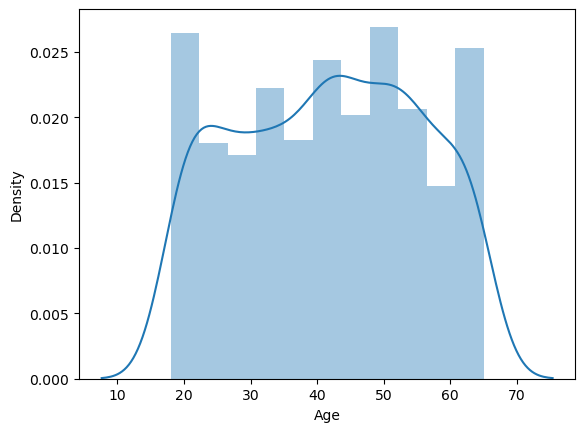

In [48]:
sns.distplot(df["Age"])            #data is highly spread

In [49]:
df["Age"].kurtosis()      #it is less peaked

-1.1381328236854327

In [50]:
df["Age"].skew()       # it is slightly left skewed

-0.04759933065573039

<Axes: ylabel='Age'>

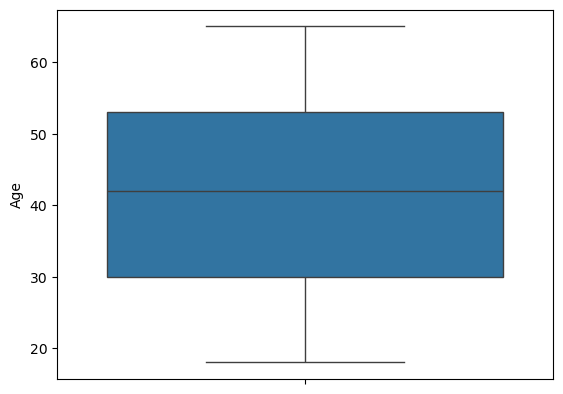

In [51]:
sns.boxplot(df["Age"])         #there is no outlier

In [52]:
import scipy.stats as stats

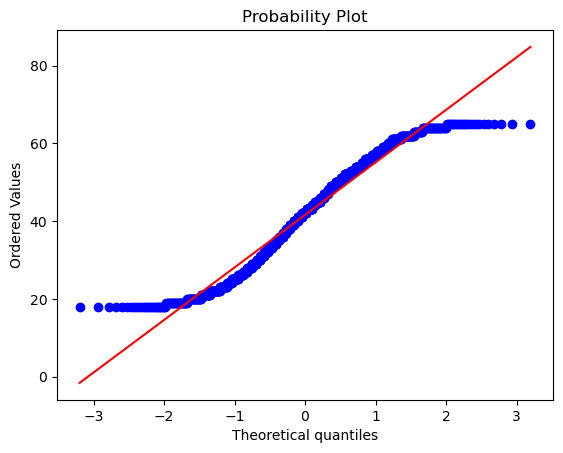

In [53]:
stats.probplot(df["Age"],dist="norm",plot=plt)             #it is not following normal distribution
plt.show()

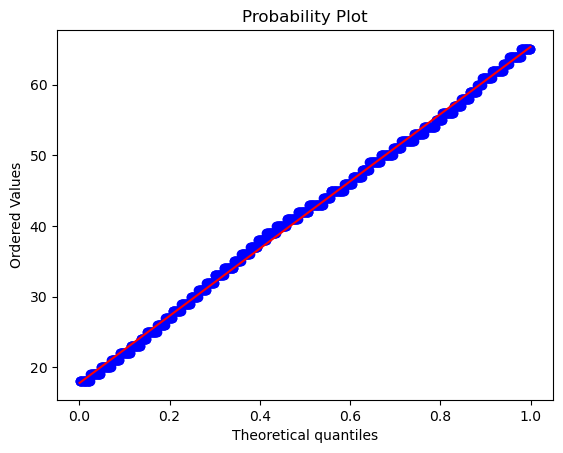

In [54]:
stats.probplot(df["Age"],dist="uniform",plot=plt)             #it is following normal distribution
plt.show()

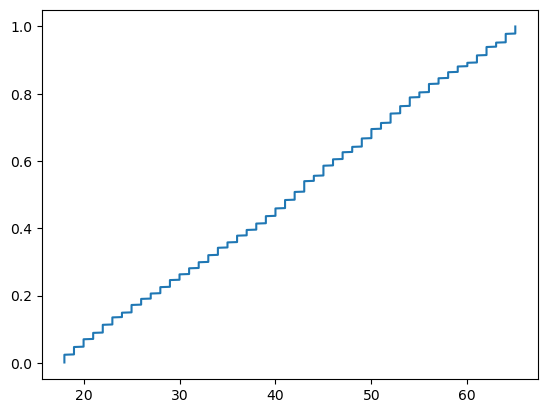

In [55]:
#CDF :-
lst_sort=np.sort(df["Age"])
cf=np.arange(1,len(lst_sort)+1)/len(lst_sort)
plt.plot(lst_sort,cf)
plt.show() # from this CDF i can conclude that the ages are evenly spread, with no age group dominating the data.

In [56]:
import scipy.stats as stats

In [57]:
# K_S Test :-
data=df["Age"]
z_score_data = (data - np.mean(data)) / np.std(data)
test_stats,p_value=stats.kstest(z_score_data,"norm")
print(test_stats,p_value)
if p_value>0.05:
    print("H0 is accepted")
else:
    print("H1 is accepted")


0.06563133281444783 0.0003450049088821179
H1 is accepted


In [58]:
# AD TEST :-
from scipy.stats import anderson
data=df["Age"]
res=anderson(data)
res
if res.statistic < res.critical_values[2]:  # 2 is a index of 5% significance level
    print("H0 is accepted and H1 is rejected")
else:
    print("H0 is rejected and H1 is accepted")

H0 is rejected and H1 is accepted


In [59]:
df.head(2)

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet
0,56,0,145,118,56.1,0,131,169,2,Low Carb
1,46,1,166,62,22.5,0,118,253,2,Diabetic


<Axes: xlabel='Gender'>

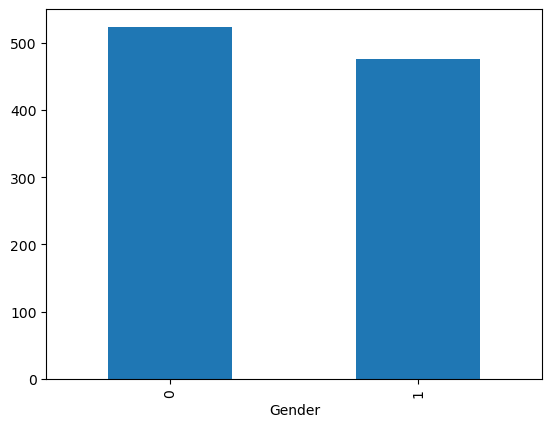

In [60]:
df["Gender"].value_counts().plot(kind="bar")

C:\Users\Mayuri\AppData\Local\Temp\ipykernel_8336\3641949933.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Height_cm"])            #data is highly spread


<Axes: xlabel='Height_cm', ylabel='Density'>

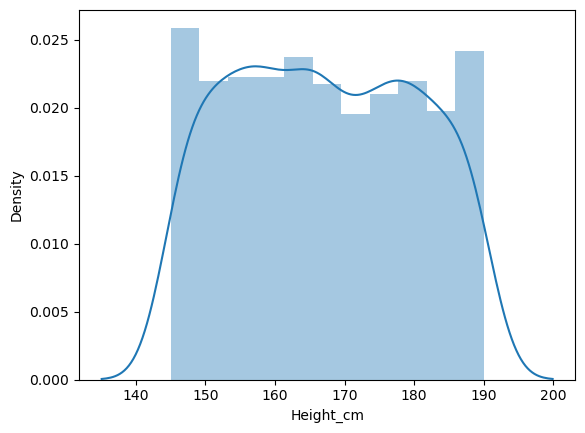

In [61]:
sns.distplot(df["Height_cm"])            #data is highly spread

In [62]:
df["Height_cm"].kurtosis()         #low peaked

-1.173676759136752

In [63]:
df["Height_cm"].skew()            #slightly right skewed

0.044068191374359196

<Axes: ylabel='Height_cm'>

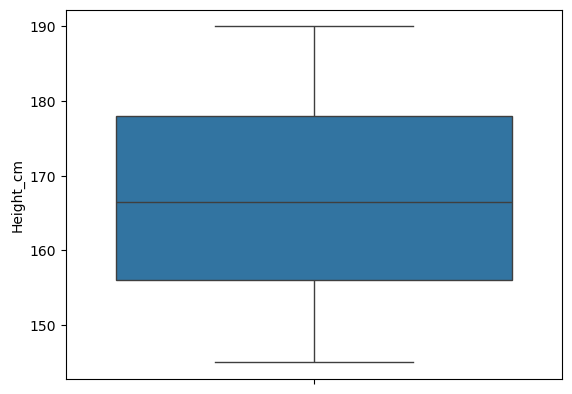

In [64]:
sns.boxplot(df["Height_cm"])      #there is no outlier

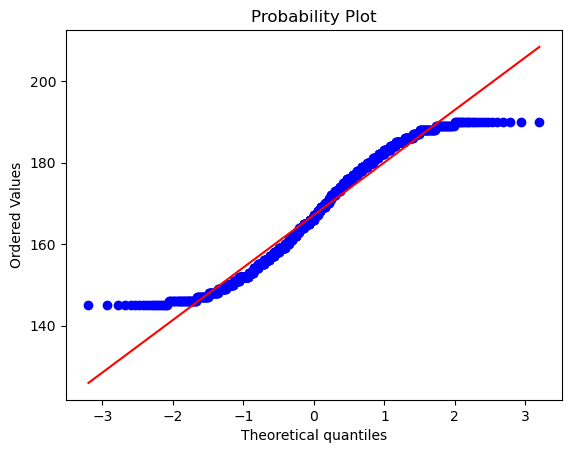

In [65]:
stats.probplot(df["Height_cm"],dist="norm",plot=plt)             #it is not following normal distribution
plt.show()

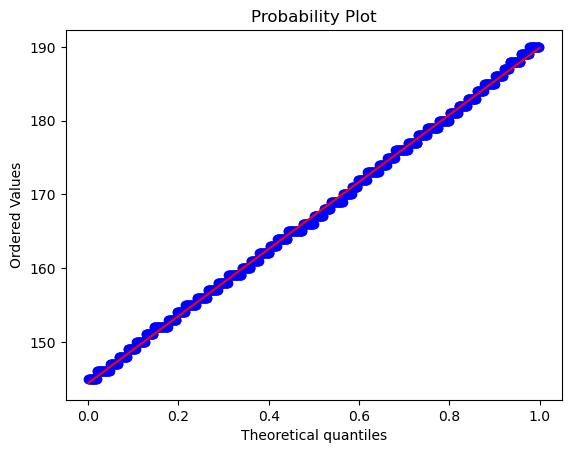

In [66]:
stats.probplot(df["Height_cm"],dist="uniform",plot=plt)             #it is following uniform distribution
plt.show()

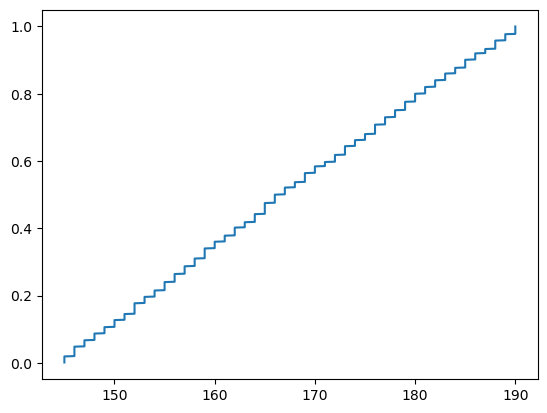

In [67]:
#CDF :-
lst_sort=np.sort(df["Height_cm"])
cf=np.arange(1,len(lst_sort)+1)/len(lst_sort)
plt.plot(lst_sort,cf)
plt.show() # from this CDF i can conclude that the heights are evenly spread.

In [68]:
# K_S Test :-
data=df["Height_cm"]
z_score_data = (data - np.mean(data)) / np.std(data)
test_stats,p_value=stats.kstest(z_score_data,"norm")
print(test_stats,p_value)
if p_value>0.05:
    print("H0 is accepted")
else:
    print("H1 is accepted")


0.07224298465934731 5.5285478325252165e-05
H1 is accepted


In [69]:
# AD TEST :-
from scipy.stats import anderson
data=df["Height_cm"]
res=anderson(data)
res
if res.statistic < res.critical_values[2]:  # 2 is a index of 5% significance level
    print("H0 is accepted and H1 is rejected")
else:
    print("H0 is rejected and H1 is accepted")

H0 is rejected and H1 is accepted


In [70]:
df.head()

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet
0,56,0,145,118,56.1,0,131,169,2,Low Carb
1,46,1,166,62,22.5,0,118,253,2,Diabetic
2,32,0,170,83,28.7,1,78,256,2,Diabetic
3,60,1,162,116,44.2,2,161,199,0,Diabetic
4,25,0,158,61,24.4,1,100,237,1,Heart Healthy


C:\Users\Mayuri\AppData\Local\Temp\ipykernel_8336\3166874447.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Weight_kg"])                    #data is highly spread


<Axes: xlabel='Weight_kg', ylabel='Density'>

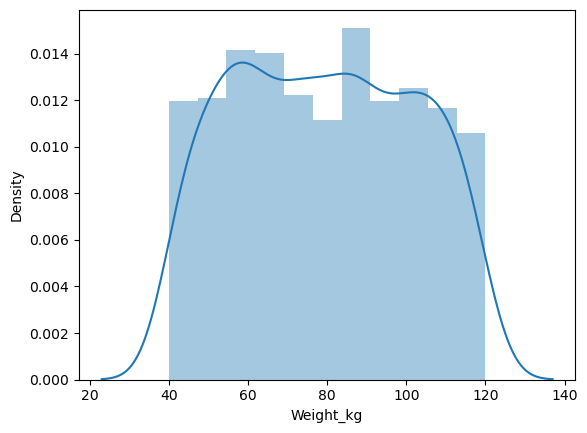

In [71]:
sns.distplot(df["Weight_kg"])                    #data is highly spread

In [72]:
df["Weight_kg"].kurtosis()               #low peaked

-1.157057418677023

In [73]:
df["Weight_kg"].skew()               #slightly right skewed

0.03912853096276925

<Axes: ylabel='Weight_kg'>

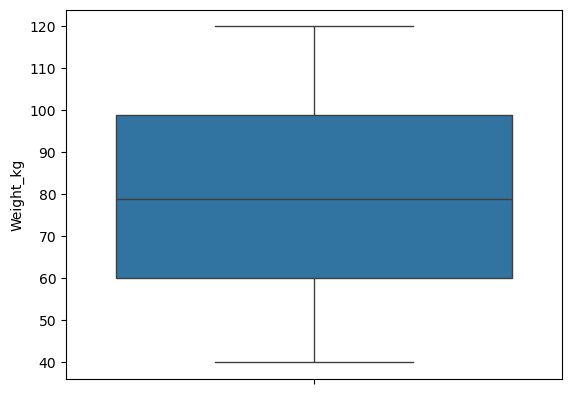

In [74]:
sns.boxplot(df["Weight_kg"])         #there is no outlier

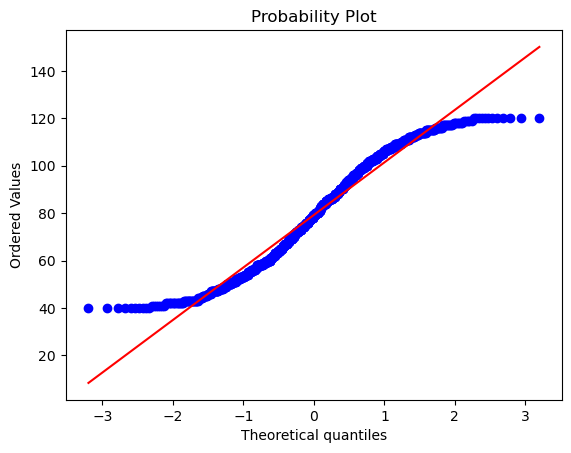

In [75]:
stats.probplot(df["Weight_kg"],dist="norm",plot=plt)             #it is not following normal distribution
plt.show()

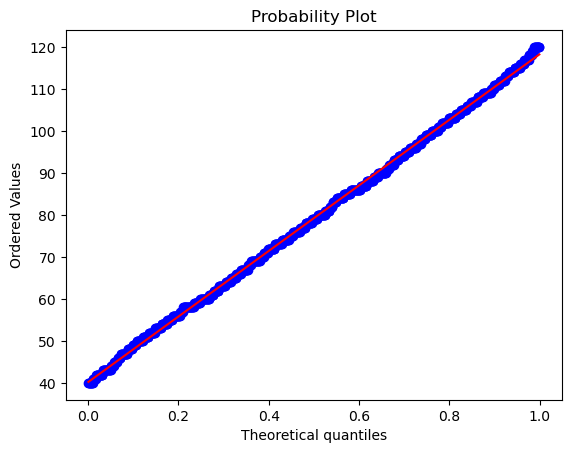

In [76]:
stats.probplot(df["Weight_kg"],dist="uniform",plot=plt)             #it is following uniform distribution
plt.show()

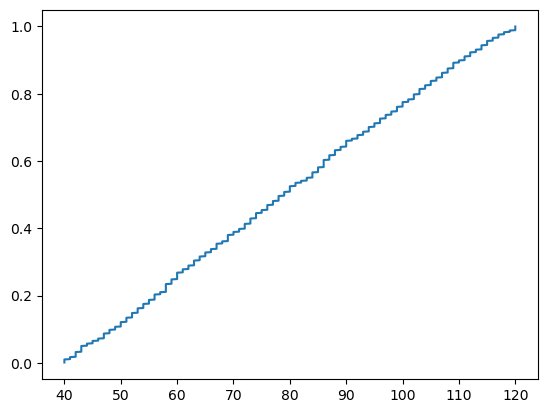

In [77]:
#CDF :-
lst_sort=np.sort(df["Weight_kg"])
cf=np.arange(1,len(lst_sort)+1)/len(lst_sort)
plt.plot(lst_sort,cf)
plt.show() # from this CDF i can conclude that the heights are evenly spread.

In [78]:
# K_S Test :-
data=df["Weight_kg"]
z_score_data = (data - np.mean(data)) / np.std(data)
test_stats,p_value=stats.kstest(z_score_data,"norm")
print(test_stats,p_value)
if p_value>0.05:
    print("H0 is accepted")
else:
    print("H1 is accepted")


0.07123212979657051 7.39843686850233e-05
H1 is accepted


In [79]:
# AD TEST :-
from scipy.stats import anderson
data=df["Weight_kg"]
res=anderson(data)
res
if res.statistic < res.critical_values[2]:  # 2 is a index of 5% significance level
    print("H0 is accepted and H1 is rejected")
else:
    print("H0 is rejected and H1 is accepted")

H0 is rejected and H1 is accepted


In [80]:
df.head(2)

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet
0,56,0,145,118,56.1,0,131,169,2,Low Carb
1,46,1,166,62,22.5,0,118,253,2,Diabetic


C:\Users\Mayuri\AppData\Local\Temp\ipykernel_8336\1594336240.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["BMI"])      #looking somewhat gaussian


<Axes: xlabel='BMI', ylabel='Density'>

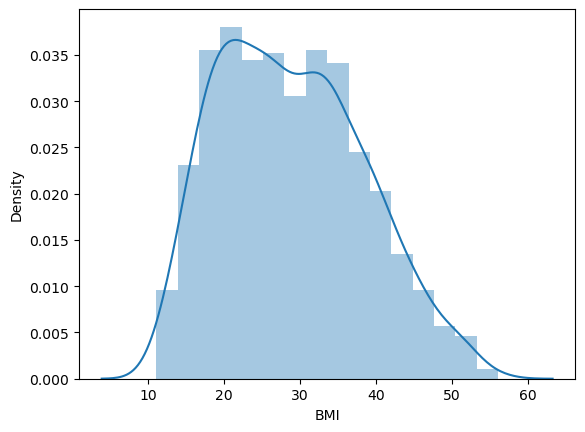

In [81]:
sns.distplot(df["BMI"])      #looking somewhat gaussian

In [82]:
df["BMI"].kurtosis()     #low peaked

-0.6090998044278337

In [83]:
df["BMI"].skew()               #right skewed

0.35848601811230857

<Axes: ylabel='BMI'>

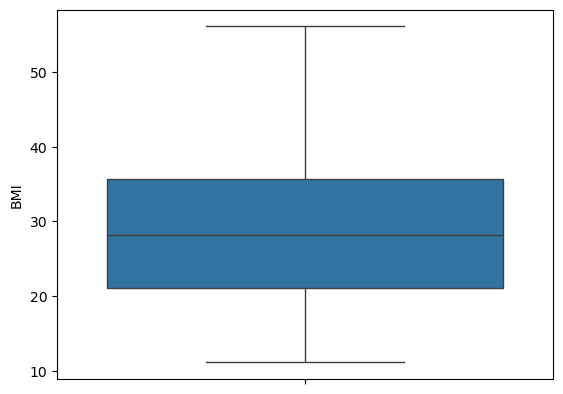

In [84]:
sns.boxplot(df["BMI"])             #there is no outlier

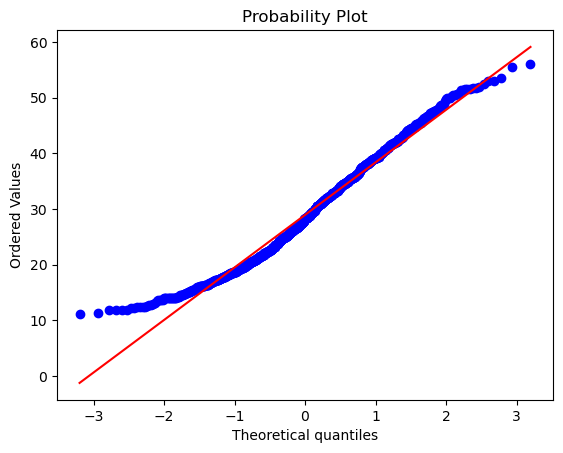

In [85]:
stats.probplot(df["BMI"],dist="norm",plot=plt)             #it is not following normal distribution
plt.show()

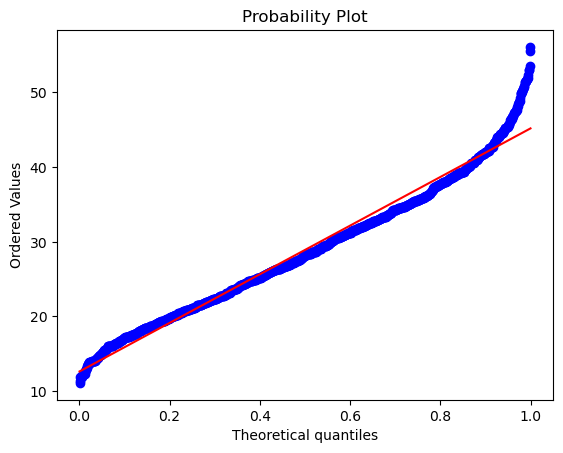

In [86]:
stats.probplot(df["BMI"],dist="uniform",plot=plt)             #approximately following the uniform distribution
plt.show()

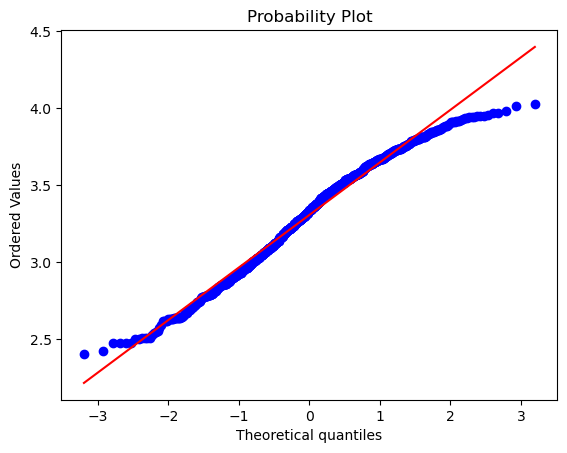

In [87]:
stats.probplot(np.log(df["BMI"]),dist="norm",plot=plt)             #it is not following log normal distribution
plt.show()

C:\Users\Mayuri\AppData\Local\Temp\ipykernel_8336\2441697493.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  return np.mean(lst),sns.distplot(lst)


(28.98113886113886, <Axes: ylabel='Density'>)

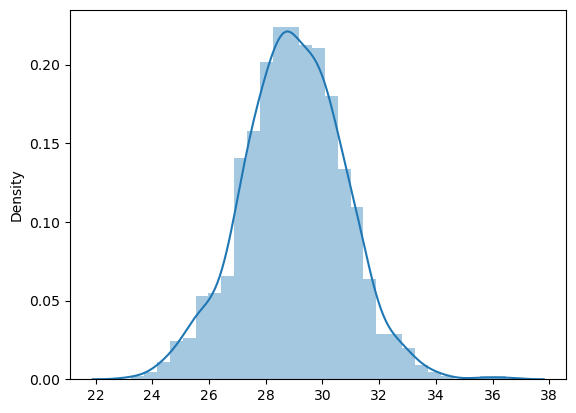

In [88]:
def clt(data):
    lst=[]
    for i in range(0,1001):
        samp=np.random.choice(data,30)
        lst.append(np.mean(samp))
    return np.mean(lst),sns.distplot(lst)
clt(df["BMI"])

In [89]:
df.head(2)

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet
0,56,0,145,118,56.1,0,131,169,2,Low Carb
1,46,1,166,62,22.5,0,118,253,2,Diabetic


<Axes: xlabel='Activity_Level'>

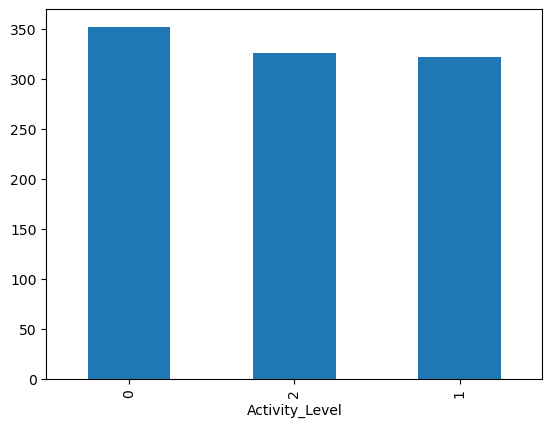

In [90]:
df["Activity_Level"].value_counts().plot(kind="bar")

In [91]:
df["Activity_Level"].value_counts()

Activity_Level
0    352
2    326
1    322
Name: count, dtype: int64

In [92]:
df.head()

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet
0,56,0,145,118,56.1,0,131,169,2,Low Carb
1,46,1,166,62,22.5,0,118,253,2,Diabetic
2,32,0,170,83,28.7,1,78,256,2,Diabetic
3,60,1,162,116,44.2,2,161,199,0,Diabetic
4,25,0,158,61,24.4,1,100,237,1,Heart Healthy


C:\Users\Mayuri\AppData\Local\Temp\ipykernel_8336\1388977505.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Sugar_Level"])                #data is highly spread


<Axes: xlabel='Sugar_Level', ylabel='Density'>

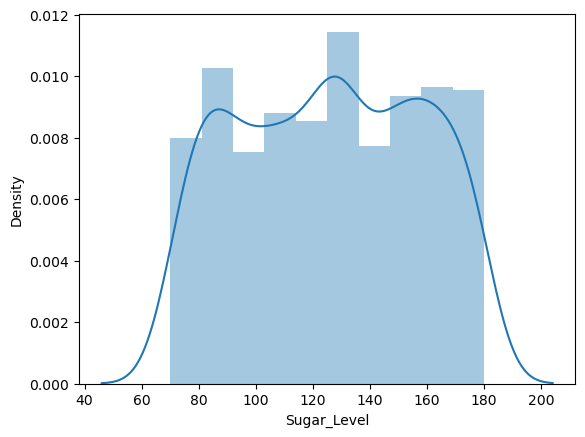

In [93]:
sns.distplot(df["Sugar_Level"])                #data is highly spread

In [94]:
df["Sugar_Level"].kurtosis()         #low peaked

-1.179376295138517

In [95]:
df["Sugar_Level"].skew()         #slightly left skewed

-0.02558448251507629

<Axes: ylabel='Sugar_Level'>

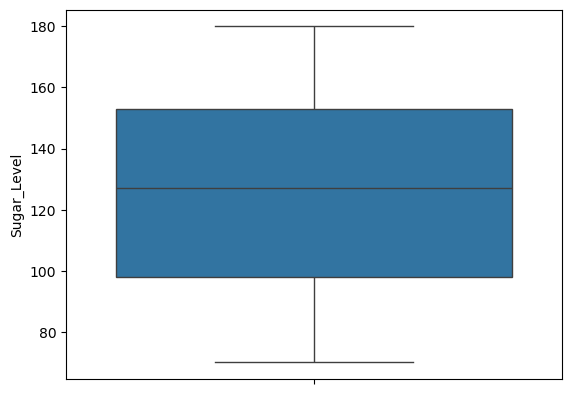

In [96]:
sns.boxplot(df["Sugar_Level"])           #there is no outlier

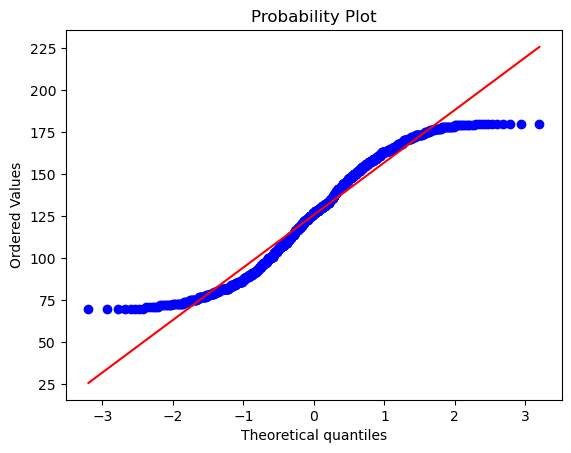

In [97]:
stats.probplot(df["Sugar_Level"],dist="norm",plot=plt)             #it is not following normal distribution
plt.show()

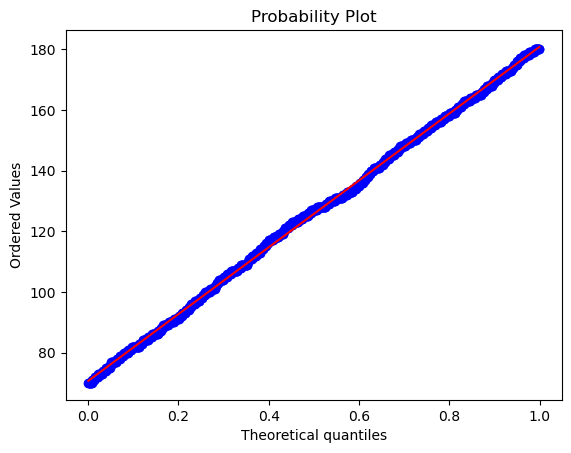

In [98]:
stats.probplot(df["Sugar_Level"],dist="uniform",plot=plt)             #it is following unifrom distribution
plt.show()

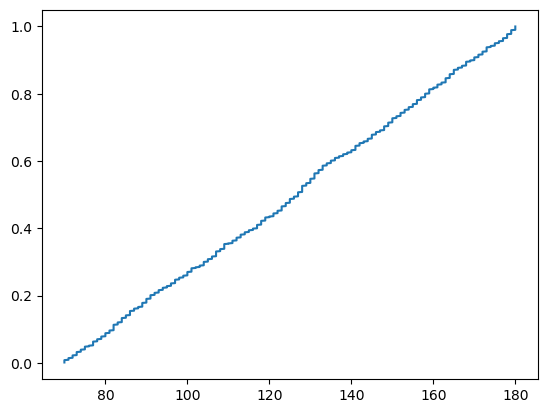

In [99]:
#CDF :-
lst_sort=np.sort(df["Sugar_Level"])
cf=np.arange(1,len(lst_sort)+1)/len(lst_sort)
plt.plot(lst_sort,cf)
plt.show() # from this CDF i can conclude that the heights are evenly spread.

In [100]:
# K_S Test :-
data=df["Sugar_Level"]
z_score_data = (data - np.mean(data)) / np.std(data)
test_stats,p_value=stats.kstest(z_score_data,"norm")
print(test_stats,p_value)
if p_value>0.05:
    print("H0 is accepted")
else:
    print("H1 is accepted")


0.06666859708125228 0.00026189141092620874
H1 is accepted


In [101]:
# AD TEST :-
from scipy.stats import anderson
data=df["Sugar_Level"]
res=anderson(data)
res
if res.statistic < res.critical_values[2]:  # 2 is a index of 5% significance level
    print("H0 is accepted and H1 is rejected")
else:
    print("H0 is rejected and H1 is accepted")

H0 is rejected and H1 is accepted


In [102]:
df.head(2)

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet
0,56,0,145,118,56.1,0,131,169,2,Low Carb
1,46,1,166,62,22.5,0,118,253,2,Diabetic


C:\Users\Mayuri\AppData\Local\Temp\ipykernel_8336\1632339026.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Cholesterol"])               #data is highly spread


<Axes: xlabel='Cholesterol', ylabel='Density'>

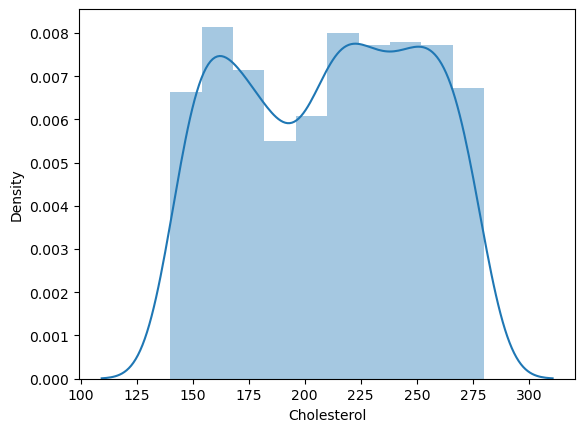

In [103]:
sns.distplot(df["Cholesterol"])               #data is highly spread

In [104]:
df["Cholesterol"].kurtosis()        #low peaked

-1.2388285597091326

In [105]:
df["Cholesterol"].skew()         #slightly left skewed

-0.06282729375439462

<Axes: ylabel='Cholesterol'>

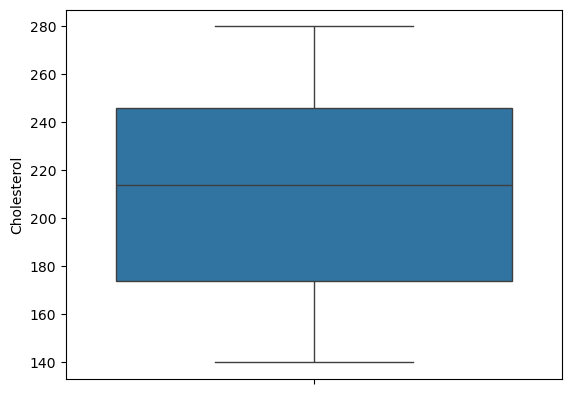

In [106]:
sns.boxplot(df["Cholesterol"])          #there is no outlier

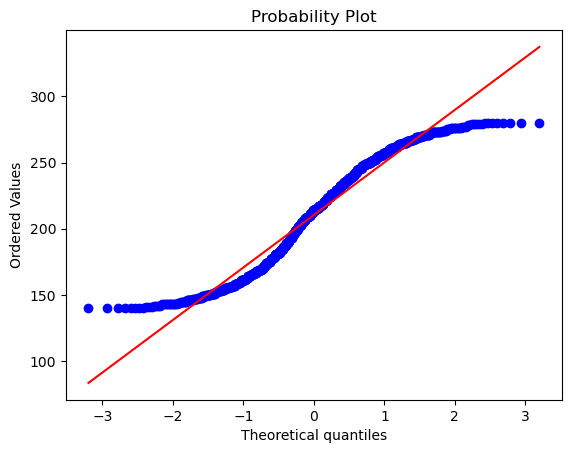

In [107]:
stats.probplot(df["Cholesterol"],dist="norm",plot=plt)             #it is not following normal distribution
plt.show()

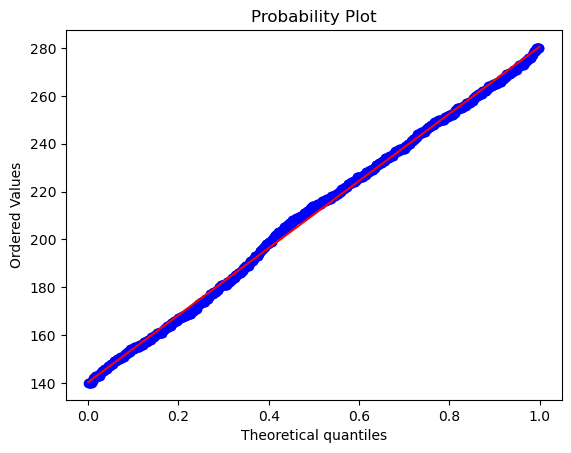

In [108]:
stats.probplot(df["Cholesterol"],dist="uniform",plot=plt)             #it is following uniform distribution
plt.show()

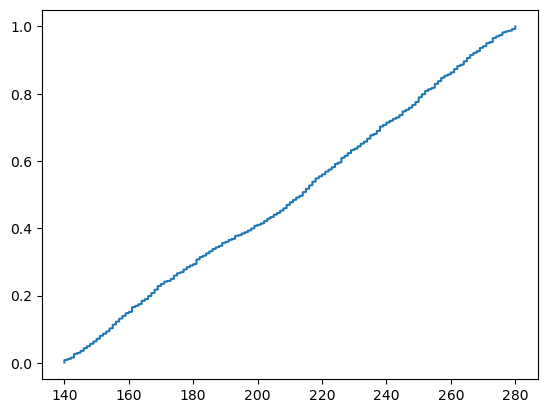

In [109]:
#CDF :-
lst_sort=np.sort(df["Cholesterol"])
cf=np.arange(1,len(lst_sort)+1)/len(lst_sort)
plt.plot(lst_sort,cf)
plt.show() # from this CDF i can conclude that the heights are evenly spread.

In [110]:
# K_S Test :-
data=df["Cholesterol"]
z_score_data = (data - np.mean(data)) / np.std(data)
test_stats,p_value=stats.kstest(z_score_data,"norm")
print(test_stats,p_value)
if p_value>0.05:
    print("H0 is accepted")
else:
    print("H1 is accepted")


0.07593821085817393 1.840215301744915e-05
H1 is accepted


In [111]:
# AD TEST :-
from scipy.stats import anderson
data=df["Cholesterol"]
res=anderson(data)
res
if res.statistic < res.critical_values[2]:  # 2 is a index of 5% significance level
    print("H0 is accepted and H1 is rejected")
else:
    print("H0 is rejected and H1 is accepted")

H0 is rejected and H1 is accepted


In [112]:
df.head(2)

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet
0,56,0,145,118,56.1,0,131,169,2,Low Carb
1,46,1,166,62,22.5,0,118,253,2,Diabetic


<Axes: xlabel='Goal'>

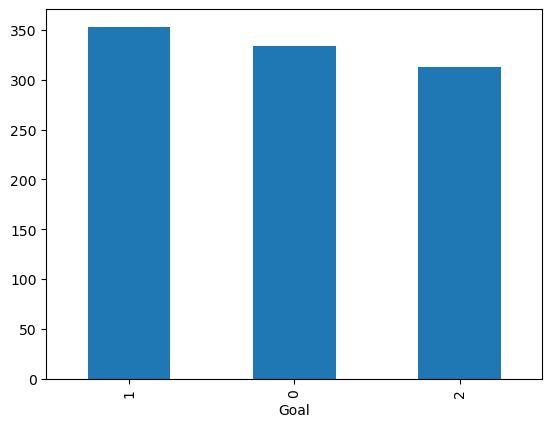

In [113]:
df["Goal"].value_counts().plot(kind="bar")

<Axes: xlabel='Diet'>

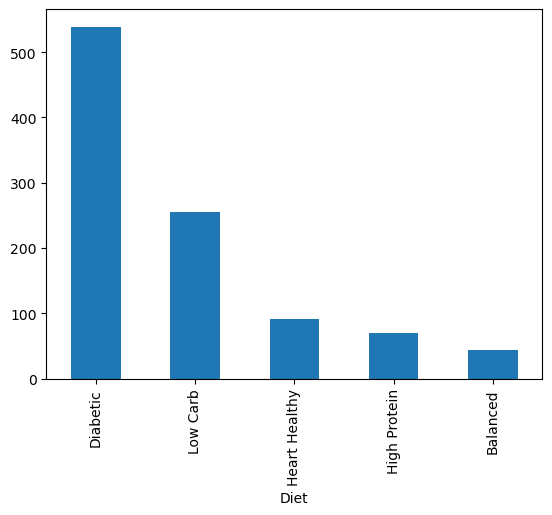

In [114]:
df["Diet"].value_counts().plot(kind="bar")

## Bivariate

In [115]:
df.head()

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet
0,56,0,145,118,56.1,0,131,169,2,Low Carb
1,46,1,166,62,22.5,0,118,253,2,Diabetic
2,32,0,170,83,28.7,1,78,256,2,Diabetic
3,60,1,162,116,44.2,2,161,199,0,Diabetic
4,25,0,158,61,24.4,1,100,237,1,Heart Healthy


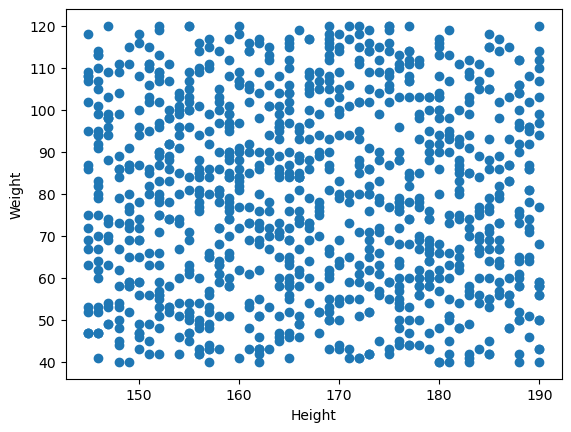

In [116]:
plt.scatter(df["Height_cm"], df["Weight_kg"])
plt.xlabel("Height")
plt.ylabel("Weight")
plt.show()
#there is a no linear raltionship between height and weight

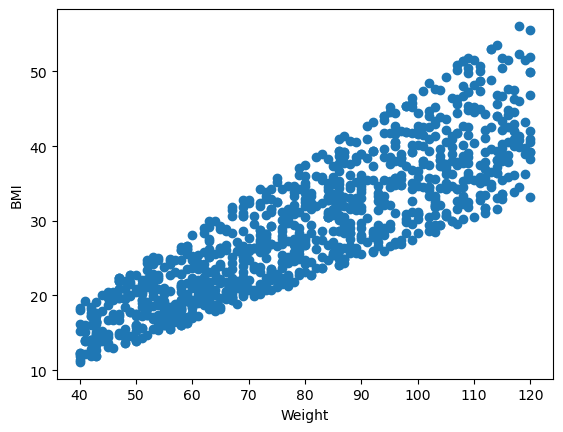

In [117]:
plt.scatter(df["Weight_kg"], df["BMI"])
plt.xlabel("Weight")
plt.ylabel("BMI")
plt.show()
#there is a positive raltionship between weight and BMI,weight increases BMI also increases

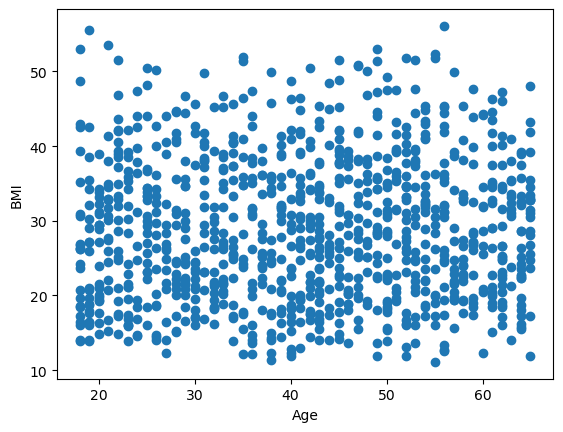

In [118]:
plt.scatter(df["Age"], df["BMI"])
plt.xlabel("Age")
plt.ylabel("BMI")
plt.show()
#there is a no linear raltionship between Age and BMI

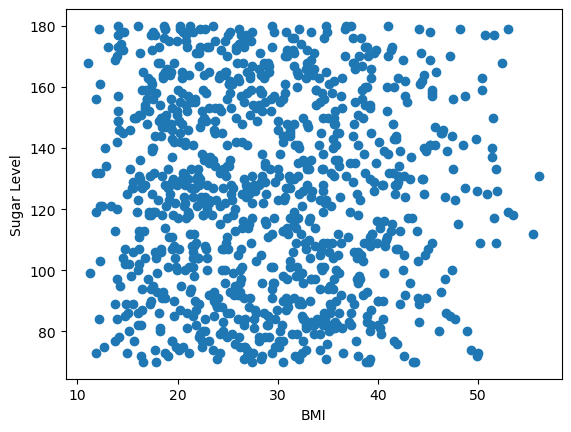

In [119]:
plt.scatter(df["BMI"], df["Sugar_Level"])
plt.xlabel("BMI")
plt.ylabel("Sugar Level")
plt.show()
#there is a no linear raltionship between Sugar level and BMI

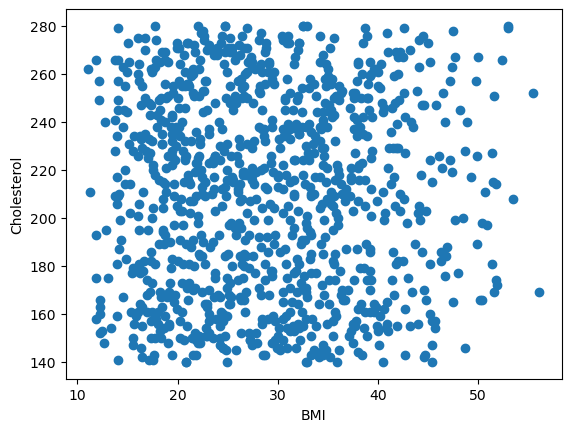

In [120]:
plt.scatter(df["BMI"], df["Cholesterol"])
plt.xlabel("BMI")
plt.ylabel("Cholesterol")
plt.show()
#there is a no linear raltionship between Cholesterol and BMI

In [121]:
from scipy.stats import chi2_contingency
# 1. Gender vs Diet 
# Question: 
# Is there a significant association between Gender and Diet type? 
# ∙ H₀: Gender and Diet are independent 
# ∙ H₁: Gender and Diet are associated 

Male_Low_Carb_Diet=df[(df["Diet"]=="Low Carb")&(df["Gender"]==0)]
Female_Low_Carb_Diet=df[(df["Diet"]=="Low Carb")&(df["Gender"]==1)]

Male_Diabetic_Diet=df[(df["Diet"]=="Diabetic")&(df["Gender"]==0)]
Female_Diabetic_Diet=df[(df["Diet"]=="Diabetic")&(df["Gender"]==1)]

Male_Heart_Healthy_Diet=df[(df["Diet"]=="Heart Healthy")&(df["Gender"]==0)]
Female_Heart_Healthy_Diet=df[(df["Diet"]=="Heart Healthy")&(df["Gender"]==1)]

Male_Balanced_Diet_Diet=df[(df["Diet"]=="Balanced_")&(df["Gender"]==0)]
Female_Balanced_Diet_Diet=df[(df["Diet"]=="Balanced")&(df["Gender"]==1)]

Male_High_Protein_Diet=df[(df["Diet"]=="High Protein")&(df["Gender"]==0)]
Female_High_Protein_Diet=df[(df["Diet"]=="High Protein")&(df["Gender"]==1)]


observed_value=np.array([[Male_Low_Carb_Diet.shape[0],Male_Diabetic_Diet.shape[0],Male_Heart_Healthy_Diet.shape[0],Male_Balanced_Diet_Diet.shape[0],Male_High_Protein_Diet.shape[0]],[Female_Low_Carb_Diet.shape[0],Female_Diabetic_Diet.shape[0],Female_Heart_Healthy_Diet.shape[0],Female_Balanced_Diet_Diet.shape[0],Female_High_Protein_Diet.shape[0]]])
stats.chi2_contingency(observed_value)

Chi2ContingencyResult(statistic=18.31032537040572, pvalue=0.0010731248457069315, dof=4, expected_freq=array([[129.99485067, 274.77342945,  46.90010299,   7.64675592,
         35.68486097],
       [125.00514933, 264.22657055,  45.09989701,   7.35324408,
         34.31513903]]))

In [122]:
# 2. Goal vs Diet
# Question:
# Does a person’s Goal (loss/maintain/gain) significantly influence the
# Diet recommended?
LowGoal_Low_Carb_Diet=df[(df["Diet"]=="Low Carb")&(df["Goal"]==0)]
ModerateGoal_Low_Carb_Diet=df[(df["Diet"]=="Low Carb")&(df["Goal"]==1)]
HighGoal_Low_Carb_Diet=df[(df["Diet"]=="Low Carb")&(df["Goal"]==2)]

LowGoal_Diabetic_Diet=df[(df["Diet"]=="Diabetic")&(df["Goal"]==0)]
ModerateGoal_Diabetic_Diet=df[(df["Diet"]=="Diabetic")&(df["Goal"]==1)]
HighGoal_Diabetic_Diet=df[(df["Diet"]=="Diabetic")&(df["Goal"]==2)]

LowGoal_Heart_Healthy_Diet=df[(df["Diet"]=="Heart Healthy")&(df["Goal"]==0)]
ModerateGoal_Heart_Healthy_Diet=df[(df["Diet"]=="Heart Healthy")&(df["Goal"]==1)]
HighGoal_Heart_Healthy=df[(df["Diet"]=="Heart Healthy")&(df["Goal"]==2)]

LowGoal_Balanced_Diet_Diet=df[(df["Diet"]=="Balanced_")&(df["Goal"]==0)]
ModerateGoal_Balanced_Diet_Diet=df[(df["Diet"]=="Balanced")&(df["Goal"]==1)]
HighGoal_Balanced_Diet_Diet=df[(df["Diet"]=="Balanced_")&(df["Goal"]==2)]

LowGoal_High_Protein_Diet=df[(df["Diet"]=="High Protein")&(df["Goal"]==0)]
ModerateGoal_High_Protein_Diet=df[(df["Diet"]=="High Protein")&(df["Goal"]==1)]
HighGoal_High_Protein_Diet=df[(df["Diet"]=="High Protein")&(df["Goal"]==2)]

observed_value=np.array([[LowGoal_Low_Carb_Diet.shape[0],LowGoal_Diabetic_Diet.shape[0],LowGoal_Heart_Healthy_Diet.shape[0],LowGoal_Balanced_Diet_Diet.shape[0],LowGoal_High_Protein_Diet.shape[0]],
                        [ModerateGoal_Low_Carb_Diet.shape[0],ModerateGoal_Diabetic_Diet.shape[0],ModerateGoal_Heart_Healthy_Diet.shape[0],ModerateGoal_Balanced_Diet_Diet.shape[0],ModerateGoal_High_Protein_Diet.shape[0]],
                        [HighGoal_Low_Carb_Diet.shape[0],HighGoal_Diabetic_Diet.shape[0],HighGoal_Heart_Healthy.shape[0],HighGoal_Balanced_Diet_Diet.shape[0],HighGoal_High_Protein_Diet.shape[0]]])
stats.chi2_contingency(observed_value)

Chi2ContingencyResult(statistic=26.90877818230253, pvalue=0.0007330880485171887, dof=8, expected_freq=array([[ 84.47368421, 178.55417957,  30.47678019,   4.30650155,
         23.18885449],
       [ 92.89473684, 196.35397317,  33.51496388,   4.73581011,
         25.500516  ],
       [ 77.63157895, 164.09184727,  28.00825593,   3.95768834,
         21.31062951]]))

In [123]:
# 3. Activity Level vs Diet
# Question:
# Is Activity_Level associated with the type of Diet suggested?

LowActivity_Low_Carb_Diet=df[(df["Diet"]=="Low Carb")&(df["Activity_Level"]==0)]
ModerateActivity_Low_Carb_Diet=df[(df["Diet"]=="Low Carb")&(df["Activity_Level"]==1)]
HighActivity_Low_Carb_Diet=df[(df["Diet"]=="Low Carb")&(df["Activity_Level"]==2)]

LowActivity_Diabetic_Diet=df[(df["Diet"]=="Diabetic")&(df["Activity_Level"]==0)]
ModerateActivity_Diabetic_Diet=df[(df["Diet"]=="Diabetic")&(df["Activity_Level"]==1)]
HighActivity_Diabetic_Diet=df[(df["Diet"]=="Diabetic")&(df["Activity_Level"]==2)]

LowActivity_Heart_Healthy_Diet=df[(df["Diet"]=="Heart Healthy")&(df["Activity_Level"]==0)]
ModerateActivity_Heart_Healthy_Diet=df[(df["Diet"]=="Heart Healthy")&(df["Activity_Level"]==1)]
HighActivity_Heart_Healthy_Diet=df[(df["Diet"]=="Heart Healthy")&(df["Activity_Level"]==2)]

LowActivity_Balanced_Diet=df[(df["Diet"]=="Balanced")&(df["Activity_Level"]==0)]
ModerateActivity_Balanced_Diet=df[(df["Diet"]=="Balanced")&(df["Activity_Level"]==1)]
HighActivity_Balanced_Diet=df[(df["Diet"]=="Balanced")&(df["Activity_Level"]==2)]

LowActivity_High_Protein_Diet=df[(df["Diet"]=="High Protein")&(df["Activity_Level"]==0)]
ModerateActivity_High_Protein_Diet=df[(df["Diet"]=="High Protein")&(df["Activity_Level"]==1)]
HighActivity_High_Protein_Diet=df[(df["Diet"]=="High Protein")&(df["Activity_Level"]==2)]

observed_value=np.array([[LowActivity_Low_Carb_Diet.shape[0],LowActivity_Diabetic_Diet.shape[0],LowActivity_Heart_Healthy_Diet.shape[0],LowActivity_Balanced_Diet.shape[0],LowActivity_High_Protein_Diet.shape[0]],
                        [ModerateActivity_Low_Carb_Diet.shape[0],ModerateActivity_Diabetic_Diet.shape[0],ModerateActivity_Heart_Healthy_Diet.shape[0],ModerateActivity_Balanced_Diet.shape[0],ModerateActivity_High_Protein_Diet.shape[0]],
                        [HighActivity_Low_Carb_Diet.shape[0],HighActivity_Diabetic_Diet.shape[0],HighActivity_Heart_Healthy_Diet.shape[0],HighActivity_Balanced_Diet.shape[0],HighActivity_High_Protein_Diet.shape[0]]])
stats.chi2_contingency(observed_value)

Chi2ContingencyResult(statistic=138.0331853879207, pvalue=6.084074397775831e-26, dof=8, expected_freq=array([[ 89.76 , 189.728,  32.384,  15.488,  24.64 ],
       [ 82.11 , 173.558,  29.624,  14.168,  22.54 ],
       [ 83.13 , 175.714,  29.992,  14.344,  22.82 ]]))

In [124]:
# 4. Gender vs Goal
# Question:
# Are fitness goals independent of gender?

Male_LowGoal=df[(df["Gender"]==0)&(df["Goal"]==0)]
Female_LowGoal=df[(df["Gender"]==1)&(df["Goal"]==0)]

Male_ModerateGoal=df[(df["Gender"]==0)&(df["Goal"]==1)]
Female_ModerateGoal=df[(df["Gender"]==1)&(df["Goal"]==1)]

Male_HighGoal=df[(df["Gender"]==0)&(df["Goal"]==2)]
Female_HighGoal=df[(df["Gender"]==1)&(df["Goal"]==2)]

observed_value=np.array([[Male_LowGoal.shape[0],Male_ModerateGoal.shape[0],Male_HighGoal.shape[0]],
                        [Female_LowGoal.shape[0],Female_ModerateGoal.shape[0],Female_HighGoal.shape[0]]])
stats.chi2_contingency(observed_value)

Chi2ContingencyResult(statistic=4.146250257090767, pvalue=0.12579205046742137, dof=2, expected_freq=array([[175.016, 184.972, 164.012],
       [158.984, 168.028, 148.988]]))

In [125]:
# 5. Diet vs BMI Category
# (Create BMI categories: Normal / Overweight / Obese)
# Question:
# Is Diet selection dependent on BMI category?
# df["BMI Category"]=df["BMI"].apply(lambda x:"Normal" if 11.1<=x<=22 else("Overweight" if 22<x<=33 else "Obese"))



In [126]:
# df["BMI Category"].value_counts()

## Multivariate

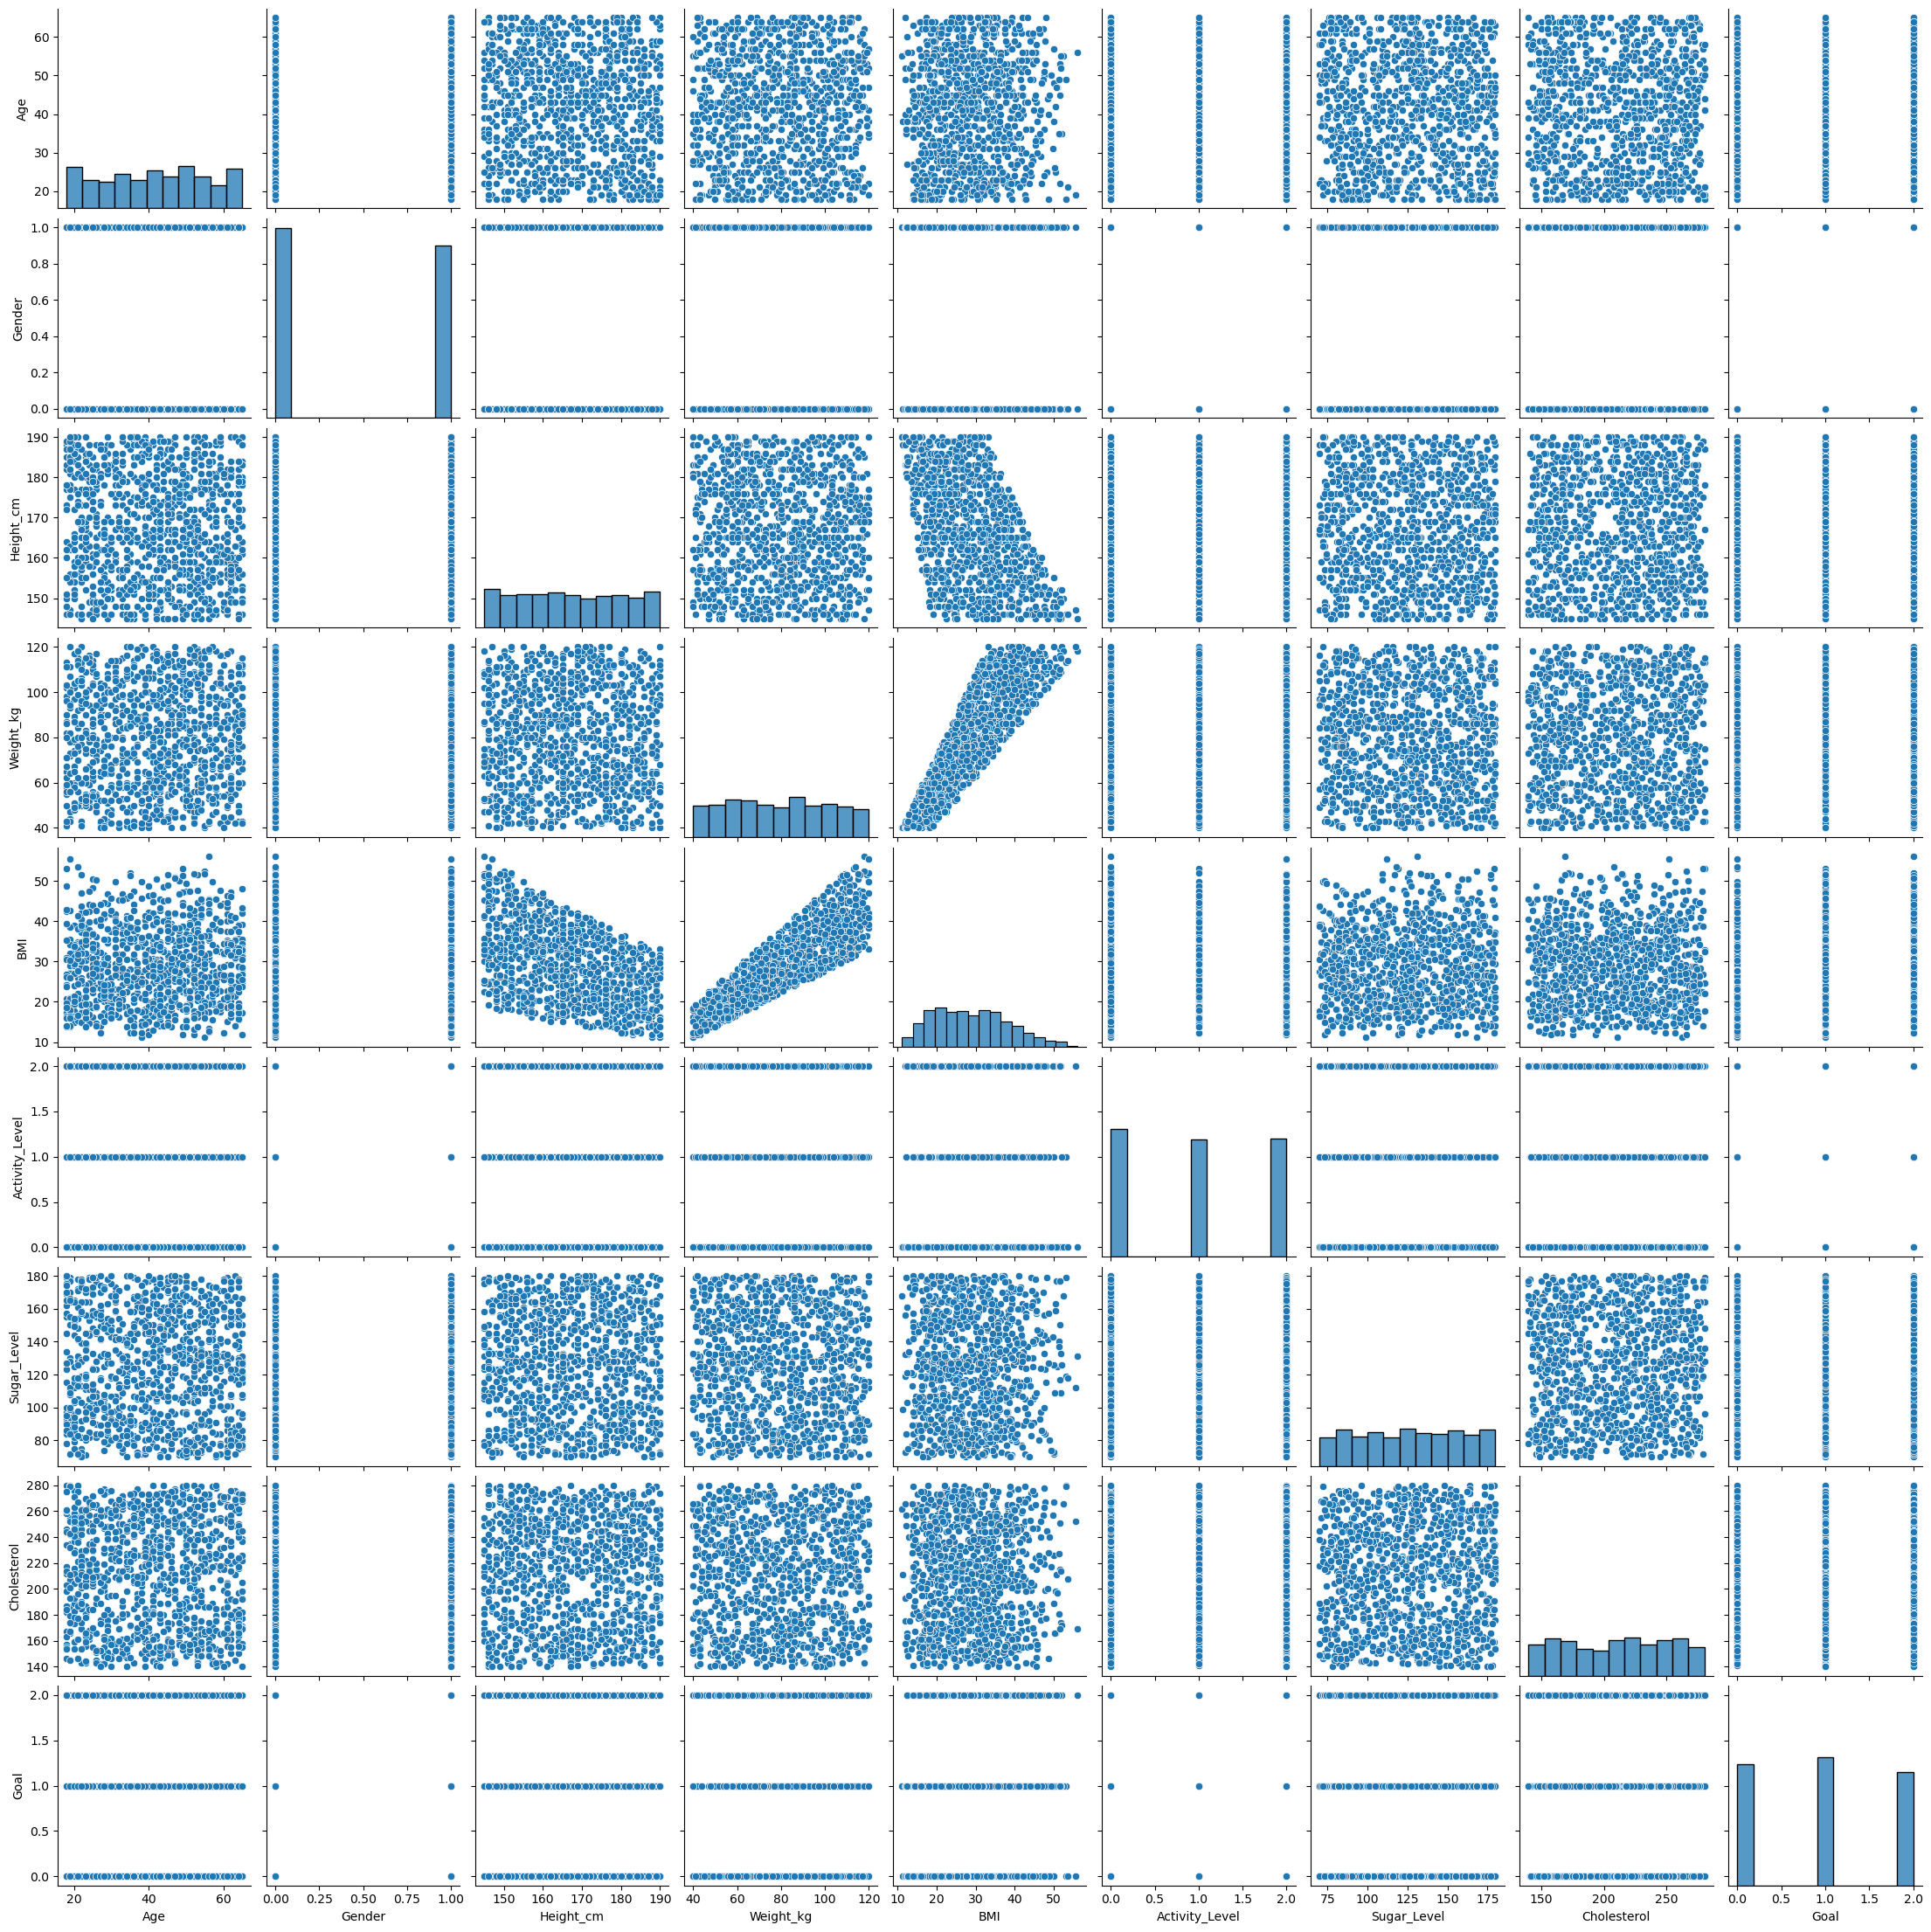

In [127]:
sns.pairplot(df)

<Axes: >

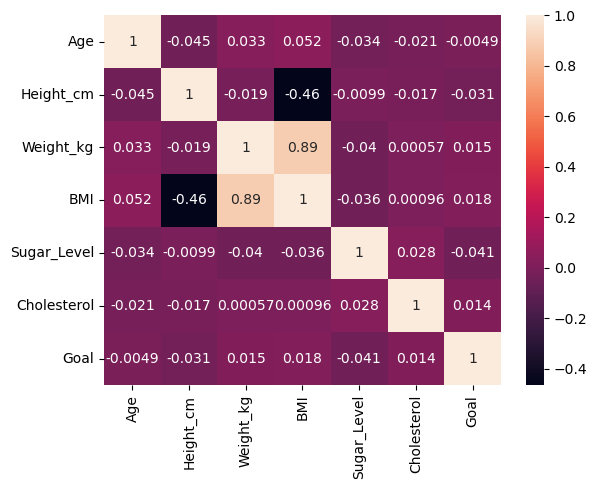

In [128]:
numeric_df=df[['Age','Height_cm','Weight_kg','BMI','Sugar_Level','Cholesterol','Goal']]
sns.heatmap(numeric_df.corr(method="spearman"),annot=True)

In [129]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler

In [130]:
ss=StandardScaler()

In [131]:
x=df.drop(columns=["Diet"])

In [132]:
x_scaled=ss.fit_transform(x)

In [133]:
x_scaled

array([[ 1.04842048, -0.9530986 , -1.68541151, ...,  0.16460264,
        -1.0232246 ,  1.26976006],
       [ 0.32161252,  1.04920939, -0.0867105 , ..., -0.24391862,
         1.04987878,  1.26976006],
       [-0.69591862, -0.9530986 ,  0.21780398, ..., -1.50090712,
         1.12391819,  1.26976006],
       ...,
       [-1.49540738, -0.9530986 , -0.61961084, ...,  0.00747908,
        -0.82578618, -1.21752703],
       [-0.40519544,  1.04920939,  0.2939326 , ...,  0.73024747,
         0.95115957, -1.21752703],
       [-0.33251464,  1.04920939,  0.59844708, ...,  1.327317  ,
        -1.22066301,  0.02611651]])

In [134]:
lof=LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05
)

In [135]:
lof_labels=lof.fit_predict(x_scaled)

In [136]:
lof_labels

array([-1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1

In [137]:
df["Lof_outlier"]=lof_labels

In [138]:
df

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet,Lof_outlier
0,56,0,145,118,56.1,0,131,169,2,Low Carb,-1
1,46,1,166,62,22.5,0,118,253,2,Diabetic,1
2,32,0,170,83,28.7,1,78,256,2,Diabetic,1
3,60,1,162,116,44.2,2,161,199,0,Diabetic,1
4,25,0,158,61,24.4,1,100,237,1,Heart Healthy,1
...,...,...,...,...,...,...,...,...,...,...,...
995,23,1,173,52,17.4,2,172,261,2,Diabetic,1
996,43,1,165,52,19.1,2,175,156,2,Diabetic,1
997,21,0,159,70,27.7,1,126,177,0,Low Carb,1
998,36,1,171,41,14.0,2,149,249,0,Diabetic,1


In [139]:
def quantile_imputation(df,lst,low=0.01,high=0.99):
    inliners=df[df["Lof_outlier"]==1]
    outliers=df[df["Lof_outlier"]==-1]
    
    for col in lst:
        LL=inliners[col].quantile(low)
        UL=inliners[col].quantile(high)
        outliers[col]=outliers[col].apply(lambda x:LL if x<LL else(UL if x>UL else x))
    new_dataframe=pd.concat([inliners, outliers])
    return new_dataframe
lst=["Age","Height_cm","Weight_kg","BMI","Sugar_Level","Cholesterol"]
new_data=quantile_imputation(df,lst)
    

C:\Users\Mayuri\AppData\Local\Temp\ipykernel_8336\104883693.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers[col]=outliers[col].apply(lambda x:LL if x<LL else(UL if x>UL else x))
C:\Users\Mayuri\AppData\Local\Temp\ipykernel_8336\104883693.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers[col]=outliers[col].apply(lambda x:LL if x<LL else(UL if x>UL else x))
C:\Users\Mayuri\AppData\Local\Temp\ipykernel_8336\104883693.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy o

In [140]:
new_data

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet,Lof_outlier
1,46,1,166,62.0,22.500,0,118.0,253.0,2,Diabetic,1
2,32,0,170,83.0,28.700,1,78.0,256.0,2,Diabetic,1
3,60,1,162,116.0,44.200,2,161.0,199.0,0,Diabetic,1
4,25,0,158,61.0,24.400,1,100.0,237.0,1,Heart Healthy,1
5,38,0,173,82.0,27.400,1,167.0,265.0,2,Diabetic,1
...,...,...,...,...,...,...,...,...,...,...,...
882,64,1,145,47.0,22.400,2,77.0,217.0,2,Balanced,-1
921,56,0,184,43.0,12.700,0,75.0,148.0,0,High Protein,-1
954,62,1,169,107.0,37.500,0,176.0,252.0,2,Diabetic,-1
982,21,1,188,112.0,31.700,0,72.0,267.0,1,Diabetic,-1


In [141]:
df.describe()

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Lof_outlier
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,41.575000,0.476000,167.139000,79.231000,28.914300,0.974000,125.762000,210.460000,0.979000,0.900000
std,13.765677,0.499674,13.142237,22.550525,9.524523,0.823409,31.838012,40.539238,0.804491,0.436108
min,18.000000,0.000000,145.000000,40.000000,11.100000,0.000000,70.000000,140.000000,0.000000,-1.000000
25%,30.000000,0.000000,156.000000,60.000000,21.100000,0.000000,98.000000,174.000000,0.000000,1.000000
50%,42.000000,0.000000,166.500000,79.000000,28.150000,1.000000,127.000000,214.000000,1.000000,1.000000
75%,53.000000,1.000000,178.000000,99.000000,35.600000,2.000000,153.000000,246.000000,2.000000,1.000000
max,65.000000,1.000000,190.000000,120.000000,56.100000,2.000000,180.000000,280.000000,2.000000,1.000000


In [142]:
new_data.describe()

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Lof_outlier
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,41.575000,0.476000,167.139000,79.231020,28.894257,0.974000,125.76151,210.455450,0.979000,0.900000
std,13.765677,0.499674,13.142237,22.547042,9.462218,0.823409,31.83718,40.496241,0.804491,0.436108
min,18.000000,0.000000,145.000000,40.000000,11.300000,0.000000,70.00000,140.000000,0.000000,-1.000000
25%,30.000000,0.000000,156.000000,60.000000,21.100000,0.000000,98.00000,174.000000,0.000000,1.000000
50%,42.000000,0.000000,166.500000,79.000000,28.150000,1.000000,127.00000,214.000000,1.000000,1.000000
75%,53.000000,1.000000,178.000000,99.000000,35.600000,2.000000,153.00000,246.000000,2.000000,1.000000
max,65.000000,1.000000,190.000000,120.000000,51.900000,2.000000,180.00000,280.000000,2.000000,1.000000


In [143]:
check_quantile1=df.select_dtypes(include="number")
quantile1=check_quantile1.quantile([0.01,0.99])

In [144]:
check_quantile2=new_data.select_dtypes(include="number")
quantile2=check_quantile2.quantile([0.01,0.99])

In [145]:
quantile1

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Lof_outlier
0.01,18.0,0.0,145.0,40.99,12.3,0.0,71.0,141.0,0.0,-1.0
0.99,65.0,1.0,190.0,120.00,51.6,2.0,180.0,279.0,2.0,1.0


In [146]:
quantile2

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Lof_outlier
0.01,18.0,0.0,145.0,41.0000,12.64553,0.0,71.0000,142.4851,0.0,-1.0
0.99,65.0,1.0,190.0,119.5149,50.30298,2.0,179.5149,277.0000,2.0,1.0


In [147]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [148]:
X=new_data.drop(columns=["Diet","Lof_outlier"])
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.fit_transform(xtest)

In [149]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)

In [150]:
from sklearn.feature_selection import SequentialFeatureSelector

In [151]:
ffs=SequentialFeatureSelector(
    model,
    n_features_to_select=5,
    direction="forward",
    scoring="accuracy",
    cv=5
)

In [152]:
ffs.fit(xtrain_scaled,ytrain)

SequentialFeatureSelector(estimator=LogisticRegression(max_iter=1000),
                          n_features_to_select=5, scoring='accuracy')

In [153]:
ffs_values=ffs.get_support()

In [154]:
x_col=X.columns

In [155]:
f_feature=[]
for i in range(len(ffs_values)):
    if ffs_values[i]==True:
        f_feature.append(x_col[i])
f_feature

['Weight_kg', 'BMI', 'Activity_Level', 'Sugar_Level', 'Cholesterol']

In [156]:
bfs=SequentialFeatureSelector(
    model,
    n_features_to_select=5,
    direction="backward",
    scoring="accuracy",
    cv=5
)

In [157]:
bfs.fit(xtrain_scaled,ytrain)

SequentialFeatureSelector(direction='backward',
                          estimator=LogisticRegression(max_iter=1000),
                          n_features_to_select=5, scoring='accuracy')

In [158]:
bfs_values=bfs.get_support()

In [159]:
b_feature=[]
for i in range(len(bfs_values)):
    if bfs_values[i]==True:
        b_feature.append(x_col[i])
b_feature

['Weight_kg', 'BMI', 'Activity_Level', 'Sugar_Level', 'Cholesterol']

In [160]:
ffs_selected=[]
for i in range(len(ffs_values)):
    if ffs_values[i]==True:
        ffs_selected.append(xtrain_scaled[i])
ffs_selected

[array([ 0.25529286, -0.92528293,  1.12996642, -1.13054455, -1.33691245,
        -1.18841381, -1.3747713 ,  0.57407635,  1.25354052]),
 array([-0.18329187, -0.92528293,  1.58953588,  1.17952014,  0.11346921,
        -1.18841381,  0.73647347,  0.20611839,  0.02457923]),
 array([ 0.91316994,  1.08075052, -1.1678809 , -0.19763381,  0.37813739,
         1.25877036,  0.0117178 ,  0.35330157, -1.20438207]),
 array([ 0.40148776, -0.92528293, -0.55512161,  1.22394446,  1.36270304,
         0.03517827,  0.57891789,  1.45717543, -1.20438207]),
 array([ 0.40148776,  1.08075052,  0.90018169, -0.50860405, -0.81816281,
         0.03517827,  1.71331807, -0.06371744,  0.02457923])]

In [161]:
bfs_selected=[]
for i in range(len(ffs_values)):
    if ffs_values[i]==True:
        bfs_selected.append(xtrain_scaled[i])
bfs_selected

[array([ 0.25529286, -0.92528293,  1.12996642, -1.13054455, -1.33691245,
        -1.18841381, -1.3747713 ,  0.57407635,  1.25354052]),
 array([-0.18329187, -0.92528293,  1.58953588,  1.17952014,  0.11346921,
        -1.18841381,  0.73647347,  0.20611839,  0.02457923]),
 array([ 0.91316994,  1.08075052, -1.1678809 , -0.19763381,  0.37813739,
         1.25877036,  0.0117178 ,  0.35330157, -1.20438207]),
 array([ 0.40148776, -0.92528293, -0.55512161,  1.22394446,  1.36270304,
         0.03517827,  0.57891789,  1.45717543, -1.20438207]),
 array([ 0.40148776,  1.08075052,  0.90018169, -0.50860405, -0.81816281,
         0.03517827,  1.71331807, -0.06371744,  0.02457923])]

In [162]:
#  Gender vs Diet 
# Question: 
# Is there a significant association between Gender and Diet type? 
# ∙ H₀: Gender and Diet are independent 
# ∙ H₁: Gender and Diet are associated 

Male_Low_Carb_Diet=df[(df["Diet"]=="Low Carb")&(df["Gender"]==0)]
Female_Low_Carb_Diet=df[(df["Diet"]=="Low Carb")&(df["Gender"]==1)]

Male_Diabetic_Diet=df[(df["Diet"]=="Diabetic")&(df["Gender"]==0)]
Female_Diabetic_Diet=df[(df["Diet"]=="Diabetic")&(df["Gender"]==1)]

Male_Heart_Healthy_Diet=df[(df["Diet"]=="Heart Healthy")&(df["Gender"]==0)]
Female_Heart_Healthy_Diet=df[(df["Diet"]=="Heart Healthy")&(df["Gender"]==1)]

Male_Balanced_Diet_Diet=df[(df["Diet"]=="Balanced_")&(df["Gender"]==0)]
Female_Balanced_Diet_Diet=df[(df["Diet"]=="Balanced")&(df["Gender"]==1)]

Male_High_Protein_Diet=df[(df["Diet"]=="High Protein")&(df["Gender"]==0)]
Female_High_Protein_Diet=df[(df["Diet"]=="High Protein")&(df["Gender"]==1)]


observed_value=np.array([[Male_Low_Carb_Diet.shape[0],Male_Diabetic_Diet.shape[0],Male_Heart_Healthy_Diet.shape[0],Male_Balanced_Diet_Diet.shape[0],Male_High_Protein_Diet.shape[0]],[Female_Low_Carb_Diet.shape[0],Female_Diabetic_Diet.shape[0],Female_Heart_Healthy_Diet.shape[0],Female_Balanced_Diet_Diet.shape[0],Female_High_Protein_Diet.shape[0]]])
stats.chi2_contingency(observed_value)

Chi2ContingencyResult(statistic=18.31032537040572, pvalue=0.0010731248457069315, dof=4, expected_freq=array([[129.99485067, 274.77342945,  46.90010299,   7.64675592,
         35.68486097],
       [125.00514933, 264.22657055,  45.09989701,   7.35324408,
         34.31513903]]))

In [163]:
# from scipy.stats import chi2_contingency
# import numpy as np

# df["Age_category"] = df["Age"].apply(lambda x: "Minor" if x <= 18 else ("Adult" if 18 <= x <= 50 else "Senior_citizen"))

# Minor_Low_Carb_Diet = df[(df["Diet"]=="Low Carb") & (df["Age_category"]=="Minor")]
# Adult_Low_Carb_Diet = df[(df["Diet"]=="Low Carb") & (df["Age_category"]=="Adult")]
# Senior_citizen_Low_Carb_Diet = df[(df["Diet"]=="Low Carb") & (df["Age_category"]=="Senior_citizen")]

# Minor_Diabetic_Diet = df[(df["Diet"]=="Diabetic") & (df["Age_category"]=="Minor")]
# Adult_Diabetic_Diet = df[(df["Diet"]=="Diabetic") & (df["Age_category"]=="Adult")]
# Senior_citizen_Diabetic_Diet = df[(df["Diet"]=="Diabetic") & (df["Age_category"]=="Senior_citizen")]

# Minor_Heart_Healthy_Diet = df[(df["Diet"]=="Heart Healthy") & (df["Age_category"]=="Minor")]
# Adult_Heart_Healthy_Diet = df[(df["Diet"]=="Heart Healthy") & (df["Age_category"]=="Adult")]
# Senior_citizen_Heart_Healthy_Diet = df[(df["Diet"]=="Heart Healthy") & (df["Age_category"]=="Senior_citizen")]

# Minor_Balanced_Diet_Diet = df[(df["Diet"]=="Balanced") & (df["Age_category"]=="Minor")]
# Adult_Balanced_Diet_Diet = df[(df["Diet"]=="Balanced") & (df["Age_category"]=="Adult")]
# Senior_citizen_Balanced_Diet_Diet = df[(df["Diet"]=="Balanced") & (df["Age_category"]=="Senior_citizen")]

# Minor_High_Protein_Diet = df[(df["Diet"]=="High Protein") & (df["Age_category"]=="Minor")]
# Adult_High_Protein_Diet = df[(df["Diet"]=="High Protein") & (df["Age_category"]=="Adult")]
# Senior_citizen_High_Protein_Diet = df[(df["Diet"]=="High Protein") & (df["Age_category"]=="Senior_citizen")]

# observed_value = np.array([
#     [Minor_Low_Carb_Diet.shape[0], Minor_Diabetic_Diet.shape[0], Minor_Heart_Healthy_Diet.shape[0], Minor_Balanced_Diet_Diet.shape[0], Minor_High_Protein_Diet.shape[0]],
#     [Adult_Low_Carb_Diet.shape[0], Adult_Diabetic_Diet.shape[0], Adult_Heart_Healthy_Diet.shape[0], Adult_Balanced_Diet_Diet.shape[0], Adult_High_Protein_Diet.shape[0]],
#     [Senior_citizen_Low_Carb_Diet.shape[0], Senior_citizen_Diabetic_Diet.shape[0], Senior_citizen_Heart_Healthy_Diet.shape[0], Senior_citizen_Balanced_Diet_Diet.shape[0], Senior_citizen_High_Protein_Diet.shape[0]]
# ])
# # observed_value
# stats.chi2_contingency(observed_value)

In [164]:
dtrain_col=xtrain.columns
dtrain_dtest_dist=[]
for i in dtrain_col:
    test_stats,p_value=stats.kstest(xtrain[i],xtest[i],"norm")
    dtrain_dtest_dist.append([i,test_stats,p_value])
dtrain_dtest_dist





[['Age', 0.04375, 0.9117201049285875],
 ['Gender', 0.07375, 0.3392949367249447],
 ['Height_cm', 0.0475, 0.8533236015388285],
 ['Weight_kg', 0.04625, 0.874295822949535],
 ['BMI', 0.05, 0.8076312171824562],
 ['Activity_Level', 0.03, 0.9983239159810353],
 ['Sugar_Level', 0.0275, 0.9996095195933874],
 ['Cholesterol', 0.075, 0.3197833534074297],
 ['Goal', 0.04125, 0.9423292118156801]]

In [165]:
from scipy.stats import ks_2samp
dtrain_col=xtrain.columns
dtrain_dtest_dist=[]
for i in dtrain_col:
    ks_stat, p_value = stats.ks_2samp(xtrain[i],xtest[i])
    dtrain_dtest_dist.append([i, ks_stat, p_value])
dtrain_dtest_dist

[['Age', 0.04375, 0.9117201049285875],
 ['Gender', 0.07375, 0.3392949367249447],
 ['Height_cm', 0.0475, 0.8533236015388285],
 ['Weight_kg', 0.04625, 0.874295822949535],
 ['BMI', 0.05, 0.8076312171824562],
 ['Activity_Level', 0.03, 0.9983239159810353],
 ['Sugar_Level', 0.0275, 0.9996095195933874],
 ['Cholesterol', 0.075, 0.3197833534074297],
 ['Goal', 0.04125, 0.9423292118156801]]

In [166]:
from scipy.stats import ks_2samp

dtrain_col = xtrain.columns
dtrain_dtest_dist = []

for i in dtrain_col:
    ks_stat, p_value = ks_2samp(
        xtrain[i],
        xtest[i]
    )
    dtrain_dtest_dist.append([i, ks_stat, p_value])

dtrain_dtest_dist


[['Age', 0.04375, 0.9117201049285875],
 ['Gender', 0.07375, 0.3392949367249447],
 ['Height_cm', 0.0475, 0.8533236015388285],
 ['Weight_kg', 0.04625, 0.874295822949535],
 ['BMI', 0.05, 0.8076312171824562],
 ['Activity_Level', 0.03, 0.9983239159810353],
 ['Sugar_Level', 0.0275, 0.9996095195933874],
 ['Cholesterol', 0.075, 0.3197833534074297],
 ['Goal', 0.04125, 0.9423292118156801]]

In [167]:
from scipy.stats import pearsonr
corr,p_value=pearsonr(new_data["Weight_kg"],new_data["BMI"])

In [168]:
corr

0.8714224398094655

In [169]:
from sklearn.model_selection import StratifiedGroupKFold,cross_val_score
from sklearn.linear_model import LogisticRegression

In [170]:
model=LogisticRegression(max_iter=1000)

In [171]:
cv=StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=42)

In [172]:
x_data_with_weight=new_data[['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal']]

In [173]:
y=new_data["Diet"]

In [174]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
y=lb.fit_transform(y)

In [175]:
accuracy_with_weight=cross_val_score(model,X=x_data_with_weight,y=y,cv=5,scoring="accuracy")

C:\Users\Mayuri\Documents\Custom Office Templates\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Mayuri\Documents\Custom Office Templates\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modul

In [176]:
accuracy_with_weight.mean()

0.7950000000000002

In [177]:
x_data_without_weight=new_data[['Age', 'Gender', 'Height_cm', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal']]

In [178]:
accuracy_without_weight=cross_val_score(model,X=x_data_without_weight,y=y,cv=5,scoring="accuracy")

C:\Users\Mayuri\Documents\Custom Office Templates\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Mayuri\Documents\Custom Office Templates\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modul

In [179]:
accuracy_without_weight.mean()

0.776

In [180]:
new_data.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal', 'Diet', 'Lof_outlier'],
      dtype='object')

In [181]:
from scipy.stats import pearsonr
corr,p_value=pearsonr(new_data["Height_cm"],new_data["BMI"])

In [182]:
corr

-0.4865967299938958

In [183]:
from scipy.stats import chi2_contingency
# 1. Gender vs Diet 
# Question: 
# Is there a significant association between Gender and Diet type? 
# ∙ H₀: Gender and Diet are independent 
# ∙ H₁: Gender and Diet are associated 

Male_Low_Carb_Diet=new_data[(new_data["Diet"]=="Low Carb")&(new_data["Gender"]==0)]
Female_Low_Carb_Diet=new_data[(new_data["Diet"]=="Low Carb")&(new_data["Gender"]==1)]

Male_Diabetic_Diet=new_data[(new_data["Diet"]=="Diabetic")&(new_data["Gender"]==0)]
Female_Diabetic_Diet=new_data[(new_data["Diet"]=="Diabetic")&(new_data["Gender"]==1)]

Male_Heart_Healthy_Diet=new_data[(new_data["Diet"]=="Heart Healthy")&(new_data["Gender"]==0)]
Female_Heart_Healthy_Diet=new_data[(new_data["Diet"]=="Heart Healthy")&(new_data["Gender"]==1)]

Male_Balanced_Diet_Diet=new_data[(new_data["Diet"]=="Balanced_")&(new_data["Gender"]==0)]
Female_Balanced_Diet_Diet=new_data[(new_data["Diet"]=="Balanced")&(new_data["Gender"]==1)]

Male_High_Protein_Diet=new_data[(new_data["Diet"]=="High Protein")&(new_data["Gender"]==0)]
Female_High_Protein_Diet=new_data[(new_data["Diet"]=="High Protein")&(new_data["Gender"]==1)]


observed_value=np.array([[Male_Low_Carb_Diet.shape[0],Male_Diabetic_Diet.shape[0],Male_Heart_Healthy_Diet.shape[0],Male_Balanced_Diet_Diet.shape[0],Male_High_Protein_Diet.shape[0]],[Female_Low_Carb_Diet.shape[0],Female_Diabetic_Diet.shape[0],Female_Heart_Healthy_Diet.shape[0],Female_Balanced_Diet_Diet.shape[0],Female_High_Protein_Diet.shape[0]]])
stats.chi2_contingency(observed_value)

Chi2ContingencyResult(statistic=18.31032537040572, pvalue=0.0010731248457069315, dof=4, expected_freq=array([[129.99485067, 274.77342945,  46.90010299,   7.64675592,
         35.68486097],
       [125.00514933, 264.22657055,  45.09989701,   7.35324408,
         34.31513903]]))

In [184]:
x_data_with_Gender=new_data[['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal']]

In [185]:
accuracy_with_gender=cross_val_score(model,X=x_data_with_Gender,y=y,cv=5,scoring="accuracy")

C:\Users\Mayuri\Documents\Custom Office Templates\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Mayuri\Documents\Custom Office Templates\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modul

In [186]:
accuracy_with_gender.mean()

0.7950000000000002

In [187]:
x_data_without_Gender=new_data[['Age', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal']]

In [188]:
accuracy_without_gender=cross_val_score(model,X=x_data_without_Gender,y=y,cv=5,scoring="accuracy")

C:\Users\Mayuri\Documents\Custom Office Templates\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Mayuri\Documents\Custom Office Templates\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modul

In [189]:
accuracy_without_gender.mean()

0.792

In [190]:
new_data.head(2)

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet,Lof_outlier
1,46,1,166,62.0,22.5,0,118.0,253.0,2,Diabetic,1
2,32,0,170,83.0,28.7,1,78.0,256.0,2,Diabetic,1


In [191]:
# from scipy.stats import chi2_contingency
# import numpy as np

# new_data["Age_category"] = new_data["Age"].apply(lambda x: "Minor" if x <= 18 else ("Adult" if 18 <= x <= 50 else "Senior_citizen"))

# Minor_Low_Carb_Diet = new_data[(new_data["Diet"]=="Low Carb") & (new_data["Age_category"]=="Minor")]
# Adult_Low_Carb_Diet = new_data[(new_data["Diet"]=="Low Carb") & (new_data["Age_category"]=="Adult")]
# Senior_citizen_Low_Carb_Diet = new_data[(new_data["Diet"]=="Low Carb") & (new_data["Age_category"]=="Senior_citizen")]

# Minor_Diabetic_Diet = new_data[(new_data["Diet"]=="Diabetic") & (new_data["Age_category"]=="Minor")]
# Adult_Diabetic_Diet = new_data[(new_data["Diet"]=="Diabetic") & (new_data["Age_category"]=="Adult")]
# Senior_citizen_Diabetic_Diet = new_data[(new_data["Diet"]=="Diabetic") & (new_data["Age_category"]=="Senior_citizen")]

# Minor_Heart_Healthy_Diet = new_data[(new_data["Diet"]=="Heart Healthy") & (new_data["Age_category"]=="Minor")]
# Adult_Heart_Healthy_Diet = new_data[(new_data["Diet"]=="Heart Healthy") & (new_data["Age_category"]=="Adult")]
# Senior_citizen_Heart_Healthy_Diet = new_data[(new_data["Diet"]=="Heart Healthy") & (new_data["Age_category"]=="Senior_citizen")]

# Minor_Balanced_Diet_Diet = new_data[(new_data["Diet"]=="Balanced") & (new_data["Age_category"]=="Minor")]
# Adult_Balanced_Diet_Diet = new_data[(new_data["Diet"]=="Balanced") & (new_data["Age_category"]=="Adult")]
# Senior_citizen_Balanced_Diet_Diet = new_data[(new_data["Diet"]=="Balanced") & (new_data["Age_category"]=="Senior_citizen")]

# Minor_High_Protein_Diet = new_data[(new_data["Diet"]=="High Protein") & (new_data["Age_category"]=="Minor")]
# Adult_High_Protein_Diet = new_data[(new_data["Diet"]=="High Protein") & (new_data["Age_category"]=="Adult")]
# Senior_citizen_High_Protein_Diet = new_data[(new_data["Diet"]=="High Protein") & (new_data["Age_category"]=="Senior_citizen")]

# observed_value = np.array([
#     [Minor_Low_Carb_Diet.shape[0], Minor_Diabetic_Diet.shape[0], Minor_Heart_Healthy_Diet.shape[0], Minor_Balanced_Diet_Diet.shape[0], Minor_High_Protein_Diet.shape[0]],
#     [Adult_Low_Carb_Diet.shape[0], Adult_Diabetic_Diet.shape[0], Adult_Heart_Healthy_Diet.shape[0], Adult_Balanced_Diet_Diet.shape[0], Adult_High_Protein_Diet.shape[0]],
#     [Senior_citizen_Low_Carb_Diet.shape[0], Senior_citizen_Diabetic_Diet.shape[0], Senior_citizen_Heart_Healthy_Diet.shape[0], Senior_citizen_Balanced_Diet_Diet.shape[0], Senior_citizen_High_Protein_Diet.shape[0]]
# ])
# # observed_value
# stats.chi2_contingency(observed_value)

In [192]:
x_data_with_Age=new_data[['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal']]


In [193]:
accuracy_with_age=cross_val_score(model,X=x_data_with_Age,y=y,cv=5,scoring="accuracy")

C:\Users\Mayuri\Documents\Custom Office Templates\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Mayuri\Documents\Custom Office Templates\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modul

In [194]:
accuracy_with_age.mean()

0.7950000000000002

In [195]:
x_data_without_Age=new_data[[ 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal']]

In [196]:
accuracy_without_age=cross_val_score(model,X=x_data_without_Age,y=y,cv=5,scoring="accuracy")

C:\Users\Mayuri\Documents\Custom Office Templates\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Mayuri\Documents\Custom Office Templates\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modul

In [197]:
accuracy_without_age.mean()

0.786

In [198]:
from scipy.stats import chi2_contingency
import numpy as np

LowGoal_Low_Carb_Diet=new_data[(new_data["Diet"]=="Low Carb")&(new_data["Goal"]==0)]
ModerateGoal_Low_Carb_Diet=new_data[(new_data["Diet"]=="Low Carb")&(new_data["Goal"]==1)]
HighGoal_Low_Carb_Diet=new_data[(new_data["Diet"]=="Low Carb")&(new_data["Goal"]==2)]

LowGoal_Diabetic_Diet=new_data[(new_data["Diet"]=="Diabetic")&(new_data["Goal"]==0)]
ModerateGoal_Diabetic_Diet=new_data[(new_data["Diet"]=="Diabetic")&(new_data["Goal"]==1)]
HighGoal_Diabetic_Diet=new_data[(new_data["Diet"]=="Diabetic")&(new_data["Goal"]==2)]

LowGoal_Heart_Healthy_Diet=new_data[(new_data["Diet"]=="Heart Healthy")&(new_data["Goal"]==0)]
ModerateGoal_Heart_Healthy_Diet=new_data[(new_data["Diet"]=="Heart Healthy")&(new_data["Goal"]==1)]
HighGoal_Heart_Healthy_Diet=new_data[(new_data["Diet"]=="Heart Healthy")&(new_data["Goal"]==2)]

LowGoal_Balanced_Diet=new_data[(new_data["Diet"]=="Balanced")&(new_data["Goal"]==0)]
ModerateGoal_Balanced_Diet=new_data[(new_data["Diet"]=="Balanced")&(new_data["Goal"]==1)]
HighGoal_Balanced_Diet=new_data[(new_data["Diet"]=="Balanced")&(new_data["Goal"]==2)]

LowGoal_High_Protein_Diet=new_data[(new_data["Diet"]=="High Protein")&(new_data["Goal"]==0)]
ModerateGoal_High_Protein_Diet=new_data[(new_data["Diet"]=="High Protein")&(new_data["Goal"]==1)]
HighGoal_High_Protein_Diet=new_data[(new_data["Diet"]=="High Protein")&(new_data["Goal"]==2)]

observed_value = np.array([[LowGoal_Low_Carb_Diet.shape[0], LowGoal_Diabetic_Diet.shape[0], LowGoal_Heart_Healthy_Diet.shape[0], LowGoal_Balanced_Diet.shape[0], LowGoal_High_Protein_Diet.shape[0]],
                           [ModerateGoal_Low_Carb_Diet.shape[0], ModerateGoal_Diabetic_Diet.shape[0], ModerateGoal_Heart_Healthy_Diet.shape[0], ModerateGoal_Balanced_Diet.shape[0], ModerateGoal_High_Protein_Diet.shape[0]], 
                           [HighGoal_Low_Carb_Diet.shape[0],HighGoal_Diabetic_Diet.shape[0],HighGoal_Heart_Healthy_Diet.shape[0],HighGoal_Balanced_Diet.shape[0],HighGoal_High_Protein_Diet.shape[0]]])
stats.chi2_contingency(observed_value)

Chi2ContingencyResult(statistic=5.847291218953, pvalue=0.6643328538921109, dof=8, expected_freq=array([[ 85.17 , 180.026,  30.728,  14.696,  23.38 ],
       [ 90.015, 190.267,  32.476,  15.532,  24.71 ],
       [ 79.815, 168.707,  28.796,  13.772,  21.91 ]]))

In [199]:
# one way Anova on Diet and Age:-
f,p=stats.f_oneway(
    new_data[new_data["Diet"]=="Low Carb"]["Age"],
    new_data[new_data["Diet"]=="Diabetic"]["Age"],
    new_data[new_data["Diet"]=="Balanced"]["Age"],
    new_data[new_data["Diet"]=="Heart Healthy"]["Age"],
    new_data[new_data["Diet"]=="High Protein"]["Age"])
print(f,p)

1.7473838047509858 0.13737037701003532


In [200]:
x_data_with_Goal=new_data[['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal']]

In [201]:
accuracy_with_goal=cross_val_score(model,X=x_data_with_Goal,y=y,cv=5,scoring="accuracy")

C:\Users\Mayuri\Documents\Custom Office Templates\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Mayuri\Documents\Custom Office Templates\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modul

In [202]:
accuracy_with_goal.mean()

0.7950000000000002

In [203]:
x_data_without_Goal=new_data[['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol']]

In [204]:
accuracy_without_goal=cross_val_score(model,X=x_data_without_Goal,y=y,cv=5,scoring="accuracy")

C:\Users\Mayuri\Documents\Custom Office Templates\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Mayuri\Documents\Custom Office Templates\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modul

In [205]:
accuracy_without_goal.mean()

0.79

In [206]:
new_data.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal', 'Diet', 'Lof_outlier'],
      dtype='object')

# Model 1 (FFS and BFS are giving same features)

In [207]:
X=new_data[['Weight_kg', 'BMI', 'Activity_Level','Sugar_Level', 'Cholesterol']]
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.fit_transform(xtest)

In [208]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5,weights="uniform",metric="manhattan")
knn.fit(xtrain_scaled,ytrain)

KNeighborsClassifier(metric='manhattan')

In [209]:
ypred=knn.predict(xtest_scaled)
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.88

# Model 2 (4 feature from FFS and 1 feature from CHI_square)

In [210]:
X=new_data[['Age', 'BMI', 'Activity_Level', 'Sugar_Level', 'Cholesterol']]
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.fit_transform(xtest)

In [211]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5,weights="uniform",metric="manhattan")
knn.fit(xtrain_scaled,ytrain)

KNeighborsClassifier(metric='manhattan')

In [212]:
ypred=knn.predict(xtest_scaled)
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.87

# Model 3 (5 features from all possible combinations of features)

In [213]:
new_data.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal', 'Diet', 'Lof_outlier'],
      dtype='object')

In [214]:
X=new_data.drop(columns=["Diet","Lof_outlier"])
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
x_scaled=ss.fit_transform(X)
model1=KNeighborsClassifier(n_neighbors=5)
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [215]:
def fun(features):
    n=len(features)
    max_score=0
    best_feature=[]
    for i in range(n):
        for j in range(i+1,n):
            for k in range(j+1,n):
                for l in range(k+1,n):
                    for m in range(l+1,n):
                        # if i!=j!=k!=l!=m:
                        tmp=x[[features[i],features[j],features[k],features[l],features[m]]]
                        accuracy=cross_val_score(model1,X=tmp,y=y,cv=cv,scoring="accuracy")
                        mean=accuracy.mean()
                        if mean>max_score:
                            max_score=mean
                            best_feature=[features[i],features[j],features[k],features[l],features[m]]
    return max_score,best_feature
features=list(x.columns)
fun(features)   

(0.511, ['Age', 'Gender', 'Weight_kg', 'BMI', 'Activity_Level'])

In [216]:
X=new_data[['Gender', 'Height_cm', 'Weight_kg', 'Cholesterol', 'Goal']]
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.fit_transform(xtest)

In [217]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5,weights="uniform",metric="manhattan")
knn.fit(xtrain_scaled,ytrain)

KNeighborsClassifier(metric='manhattan')

In [218]:
ypred=knn.predict(xtest_scaled)
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.645

# Recursive feature elimination

In [219]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression

In [220]:
X=new_data.drop(columns=["Diet","Lof_outlier"])
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.fit_transform(xtest)

In [221]:
m=LogisticRegression()

In [222]:
rfecv=RFECV(estimator=m,cv=5,min_features_to_select=5)

In [223]:
rfecv.fit(xtrain_scaled,ytrain)

RFECV(cv=5, estimator=LogisticRegression(), min_features_to_select=5)

In [224]:
rfecv.support_

array([False, False,  True,  True,  True,  True,  True,  True, False])

In [225]:
rfecv.ranking_

array([3, 4, 1, 1, 1, 1, 1, 1, 2])

In [226]:
X.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal'],
      dtype='object')

# Model 4 (selected feature using Recursive feature elimination)

In [227]:
X=new_data[['Weight_kg', 'BMI', 'Activity_Level','Sugar_Level', 'Cholesterol']]
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.fit_transform(xtest)

In [228]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5,weights="uniform",metric="manhattan")
knn.fit(xtrain_scaled,ytrain)

KNeighborsClassifier(metric='manhattan')

In [229]:
ypred=knn.predict(xtest_scaled)
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.88

# Hyperparameter Tunning

In [230]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

X=new_data.drop(columns=["Diet","Lof_outlier"])
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.fit_transform(xtest)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = KNeighborsClassifier()

param_grid = {
    'n_neighbors': range(1, 31),
    'weights': ['uniform', 'distance'],
    'algorithm': ['ball_tree', 'kd_tree', 'brute'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv
)

grid_search.fit(xtrain_scaled, ytrain)

grid_search.best_params_


{'algorithm': 'ball_tree',
 'metric': 'manhattan',
 'n_neighbors': 11,
 'weights': 'distance'}

# Model 5 (FFS and BFS are giving same features with hyperparamenter)

In [231]:
X=new_data[['Weight_kg', 'BMI', 'Activity_Level','Sugar_Level', 'Cholesterol']]
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.fit_transform(xtest)

In [232]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=14,weights="distance",metric="manhattan",algorithm="ball_tree")
knn.fit(xtrain_scaled,ytrain)

KNeighborsClassifier(algorithm='ball_tree', metric='manhattan', n_neighbors=14,
                     weights='distance')

In [233]:
ypred=knn.predict(xtest_scaled)
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.915

# Model 6 (4 feature from FFS and 1 feature from CHI_square with hyperparameter)

In [234]:
X=new_data[['Age', 'BMI', 'Activity_Level', 'Sugar_Level', 'Cholesterol']]
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.fit_transform(xtest)

In [235]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=14,weights="distance",metric="manhattan",algorithm="ball_tree")
knn.fit(xtrain_scaled,ytrain)

KNeighborsClassifier(algorithm='ball_tree', metric='manhattan', n_neighbors=14,
                     weights='distance')

In [236]:
ypred=knn.predict(xtest_scaled)
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.885

# Model 7 (5 features from all possible combinations of features with hyperparameter)

In [237]:
X=new_data[['Height_cm', 'Weight_kg', 'Activity_Level', 'Sugar_Level', 'Cholesterol']]
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.fit_transform(xtest)

In [238]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=14,weights="distance",metric="manhattan",algorithm="ball_tree")
knn.fit(xtrain_scaled,ytrain)

KNeighborsClassifier(algorithm='ball_tree', metric='manhattan', n_neighbors=14,
                     weights='distance')

In [239]:
ypred=knn.predict(xtest_scaled)
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.89

# Handling Class Imbalance using SMOTE

In [240]:
from imblearn.over_sampling import SMOTE

In [241]:
smote=SMOTE(random_state=42)

In [242]:
X=new_data.drop(columns=["Diet","Lof_outlier"])
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.fit_transform(xtest)

In [243]:
x_sampled,y_sampled=smote.fit_resample(xtrain_scaled,ytrain)

In [244]:
x_sampled.shape

(2090, 9)

In [245]:
y_sampled.shape

(2090,)

# Model 8 SMOTE(FFS and BFS are giving same features)

In [246]:
X=new_data[['Weight_kg', 'BMI', 'Activity_Level','Sugar_Level', 'Cholesterol']]
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.fit_transform(xtest)

In [247]:
x_sampled,y_sampled=smote.fit_resample(xtrain_scaled,ytrain)

In [248]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5,weights="uniform",metric="manhattan")
knn.fit(x_sampled,y_sampled)

KNeighborsClassifier(metric='manhattan')

In [249]:
ypred=knn.predict(xtest_scaled)
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.82

# Model 9 SMOTE(4 feature from FFS and 1 feature from CHI_square)

In [250]:
X=new_data[['Age', 'BMI', 'Activity_Level', 'Sugar_Level', 'Cholesterol']]
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.fit_transform(xtest)

In [251]:
x_sampled,y_sampled=smote.fit_resample(xtrain_scaled,ytrain)

In [252]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5,weights="uniform",metric="manhattan")
knn.fit(x_sampled,y_sampled)

KNeighborsClassifier(metric='manhattan')

In [253]:
ypred=knn.predict(xtest_scaled)
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.785

# Model 10 SMOTE(5 features from all possible combinations of features)

In [254]:
X=new_data[['Height_cm', 'Weight_kg', 'Activity_Level', 'Sugar_Level', 'Cholesterol']]
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.fit_transform(xtest)

In [255]:
x_sampled,y_sampled=smote.fit_resample(xtrain_scaled,ytrain)

In [256]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5,weights="uniform",metric="manhattan")
knn.fit(x_sampled,y_sampled)

KNeighborsClassifier(metric='manhattan')

In [257]:
ypred=knn.predict(xtest_scaled)
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.825

# Model 11 SMOTE(selected feature using Recursive feature elimination)

In [258]:
X=new_data[['Weight_kg', 'BMI', 'Activity_Level','Sugar_Level', 'Cholesterol']]
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.fit_transform(xtest)

In [259]:
x_sampled,y_sampled=smote.fit_resample(xtrain_scaled,ytrain)

In [260]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5,weights="uniform",metric="manhattan")
knn.fit(x_sampled,y_sampled)

KNeighborsClassifier(metric='manhattan')

In [261]:
ypred=knn.predict(xtest_scaled)
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.82

# Model 12 SMOTE(FFS and BFS are giving same features with hyperparamenter)

In [262]:
X=new_data[['Weight_kg', 'BMI', 'Activity_Level','Sugar_Level', 'Cholesterol']]
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.fit_transform(xtest)

In [263]:
x_sampled,y_sampled=smote.fit_resample(xtrain_scaled,ytrain)

In [264]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=14,weights="distance",metric="manhattan",algorithm="ball_tree")
knn.fit(x_sampled,y_sampled)

KNeighborsClassifier(algorithm='ball_tree', metric='manhattan', n_neighbors=14,
                     weights='distance')

In [265]:
ypred=knn.predict(xtest_scaled)
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.795

# Model 13 SMOTE(4 feature from FFS and 1 feature from CHI_square with hyperparameter)

In [266]:
X=new_data[['Age', 'BMI', 'Activity_Level', 'Sugar_Level', 'Cholesterol']]
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.fit_transform(xtest)

In [267]:
x_sampled,y_sampled=smote.fit_resample(xtrain_scaled,ytrain)

In [268]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=14,weights="distance",metric="manhattan",algorithm="ball_tree")
knn.fit(x_sampled,y_sampled)

KNeighborsClassifier(algorithm='ball_tree', metric='manhattan', n_neighbors=14,
                     weights='distance')

In [269]:
ypred=knn.predict(xtest_scaled)
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.76

# Model 14 SMOTE(5 features from all possible combinations of features with hyperparameter)

In [270]:
X=new_data[['Height_cm', 'Weight_kg', 'Activity_Level', 'Sugar_Level', 'Cholesterol']]
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.transform(xtest)

In [271]:
x_sampled,y_sampled=smote.fit_resample(xtrain_scaled,ytrain)

In [272]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=14,weights="distance",metric="manhattan",algorithm="ball_tree")
knn.fit(x_sampled,y_sampled)

KNeighborsClassifier(algorithm='ball_tree', metric='manhattan', n_neighbors=14,
                     weights='distance')

In [273]:
ypred=knn.predict(xtest_scaled)
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.775

In [291]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold

X=new_data.drop(columns=["Diet","Lof_outlier"])
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.fit_transform(xtest)

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

model = KNeighborsClassifier()

param_grid = {
    'n_neighbors': range(1, 31),
    'weights': ['uniform', 'distance'],
    'algorithm': ['ball_tree', 'kd_tree', 'brute'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv
)
grid_search.fit(xtrain_scaled, ytrain)
grid_search.best_params_

{'algorithm': 'ball_tree',
 'metric': 'manhattan',
 'n_neighbors': 19,
 'weights': 'distance'}

In [290]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold

X=new_data.drop(columns=["Diet","Lof_outlier"])
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.fit_transform(xtest)

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

model = KNeighborsClassifier()

param_grid = {
    'n_neighbors': range(1, 31),
    'weights': ['uniform', 'distance'],
    'algorithm': ['ball_tree', 'kd_tree', 'brute'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv
)

grid_search.fit(xtrain_scaled, ytrain)

grid_search.best_params_


{'algorithm': 'ball_tree',
 'metric': 'manhattan',
 'n_neighbors': 17,
 'weights': 'distance'}

In [276]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [277]:
X=new_data.drop(columns=["Diet","Lof_outlier"])
y=new_data["Diet"]
lb=LabelEncoder()
y=lb.fit_transform(y)
xtrain,xtest,ytrain,ytest=train_test_split(X,y,test_size=0.2,random_state=42)
xtrain_scaled=ss.fit_transform(xtrain)
xtest_scaled=ss.transform(xtest)

In [278]:
x_sampled,y_sampled=smote.fit_resample(xtrain_scaled,ytrain)

In [279]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=12,weights="distance",metric="manhattan",algorithm="ball_tree")
knn.fit(xtrain_scaled,ytrain)

KNeighborsClassifier(algorithm='ball_tree', metric='manhattan', n_neighbors=12,
                     weights='distance')

In [280]:
ypred=knn.predict(xtest_scaled)
from sklearn.metrics import accuracy_score
accuracy_score(ytest,ypred)

0.865

In [281]:
cm=confusion_matrix(ytest,ypred)

In [282]:
cm

array([[  5,   2,   0,   0,   0],
       [  0, 112,   2,   0,   7],
       [  0,   3,  12,   0,   0],
       [  2,   3,   2,   9,   0],
       [  0,   5,   1,   0,  35]], dtype=int64)

In [283]:
print(classification_report(ytest,ypred))

              precision    recall  f1-score   support

           0       0.71      0.71      0.71         7
           1       0.90      0.93      0.91       121
           2       0.71      0.80      0.75        15
           3       1.00      0.56      0.72        16
           4       0.83      0.85      0.84        41

    accuracy                           0.86       200
   macro avg       0.83      0.77      0.79       200
weighted avg       0.87      0.86      0.86       200



In [289]:
import pickle
with open("diet_recommendation_pp.pkl","wb") as file:
    pickle.dump(knn,file)
print("Model save successfully!")

Model save successfully!


In [285]:
df.columns

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'BMI', 'Activity_Level',
       'Sugar_Level', 'Cholesterol', 'Goal', 'Diet', 'Lof_outlier'],
      dtype='object')

In [286]:
df

,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Sugar_Level,Cholesterol,Goal,Diet,Lof_outlier
0,56,0,145,118,56.1,0,131,169,2,Low Carb,-1
1,46,1,166,62,22.5,0,118,253,2,Diabetic,1
2,32,0,170,83,28.7,1,78,256,2,Diabetic,1
3,60,1,162,116,44.2,2,161,199,0,Diabetic,1
4,25,0,158,61,24.4,1,100,237,1,Heart Healthy,1
...,...,...,...,...,...,...,...,...,...,...,...
995,23,1,173,52,17.4,2,172,261,2,Diabetic,1
996,43,1,165,52,19.1,2,175,156,2,Diabetic,1
997,21,0,159,70,27.7,1,126,177,0,Low Carb,1
998,36,1,171,41,14.0,2,149,249,0,Diabetic,1


Usage: streamlit run [OPTIONS] TARGET [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py
